# Experimentos de estrutura residual e incerteza

Neste notebook, os diagnósticos residuais da validação final são tratados como motivação científica para novos experimentos, e não como uma reabertura do holdout confirmatório. O objetivo é avaliar, somente no conjunto de desenvolvimento, se a estrutura temporal da volatilidade pode ser representada por novas features, por uma função de perda probabilística ou por uma camada prequential de escala residual.

O resultado deverá ser lido como investigação controlada. Caso algum desenho seja favorecido, ele será descrito apenas como candidato sucessor experimental, pois uma confirmação exigirá uma janela independente.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

from matplotlib import pyplot as plt

from src import uncertainty_reports as reports
from src.i18n import make_lang
from src.plotting import set_graph_parameters
from src.uncertainty_experiments import (
    UncertaintyExperimentConfig,
    experiment_specs,
    prepare_uncertainty_development,
    run_uncertainty_experiments,
)

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('pt')

## 1. Objetivo e fronteira confirmatória

A validação final do Notebook 05 confirmou o `CatBoostRegressor` como melhor modelo pontual entre os candidatos congelados. Ainda assim, foi observada dependência temporal relevante nos resíduos, com persistência nos lags de 1, 24 e 168 horas e evidência ARCH mesmo após padronizações por nível e calendário.

Neste notebook, essa evidência é usada para desenvolver hipóteses novas. O holdout de dezembro de 2023 a novembro de 2024 não é usado, e dezembro de 2024 permanece fora do processo. Assim, nenhuma decisão confirmatória é tomada aqui.

In [2]:
reports.environment_report(lang=lang)

,Item,Valor
0,Ambiente conda,Bike-Sharing
1,Interpretador (sys.executable),CONDA_PREFIX\py...
2,Versão do Python,3.10.20
3,Fingerprint do ambiente,8f80d9216d47a792
4,Divergências em relação ao environment.yml,nenhuma
5,Requisitos declarados no modelo,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Ambiente, dados e proveniência

O ambiente `Bike-Sharing` é exigido antes de qualquer execução. A mesma rotina de preparação usada na seleção temporal é reaproveitada para devolver apenas o conjunto de desenvolvimento e metadados do holdout selado.

A proveniência do manifesto do Champion é mantida como referência metodológica. O pipeline é reconstruído dentro de cada fold a partir da especificação registrada, em vez de ser carregado como artefato já treinado.

In [3]:
config = UncertaintyExperimentConfig(
    run_mode='full',
    smoke_fold_limit=2,
    smoke_iterations=25,
)
reports.protocol_report(config, lang=lang)

,Item,Valor
0,Modo de execucao,full
1,Natureza da conclusao,candidato sucessor experimental
2,Uso do holdout final,nao utilizado
3,Uso de dezembro de 2024,nao utilizado
4,Protocolo temporal,ForwardMeteorologicalYearSplit sobre desenvolv...
5,Folds normais no modo smoke,todos
6,Iteracoes por CatBoost no smoke,manifesto
7,Contrato operacional residual,rolling_one_step_ahead


In [4]:
reports.artifact_hash_report([config.manifest_path.parent], lang=lang)

,Artefato,SHA256
0,PROJECT_ROOT/...,dbf4168383ce7df0ee86eb29134b1739a373cc82be022f...
1,PROJECT_ROOT/...,b27ab507627c2d1cb917ccdc2b14a4d503147dc3665f14...
2,PROJECT_ROOT/...,3518c691fe7c8db7c8db5eb46b14b8a681aa16775581cc...
3,PROJECT_ROOT/...,57195bd3badc8d9826c3383dfc3731665d1325620587db...


## 3. Protocolo temporal e bloqueio do holdout

O `ForwardMeteorologicalYearSplit` é preservado para que os experimentos sejam avaliados sob a mesma geometria temporal da seleção vigente. A estrutura respeita a cautela discutida por Bergmeir, Hyndman e Koo (2018), na qual a avaliação de séries temporais deve considerar dependência serial, não estacionariedade e erro fora da amostra. As janelas de treino seguem expansão temporal, o gap é mantido e a política `normal_operations` continua separando folds de seleção e de estresse. As horas de 2020 são mantidas apenas na cronologia e no diagnóstico de estresse; elas são excluídas do ajuste, da pontuação principal e do estado residual prequential.

O holdout final não é reaberto. O objeto disponível para o notebook contém apenas o desenvolvimento e um resumo auditável das janelas seladas.

In [5]:
development = prepare_uncertainty_development(config)
reports.development_report(development, lang=lang)

,Item,Valor
0,Periodo de desenvolvimento,19/09/2015 a 30/11/2023
1,Linhas de desenvolvimento,71490
2,Holdout selado,"sim, sem retorno de linhas"
3,Periodo posterior descartado,01/12/2024 a 31/12/2024
4,Fingerprint do dataset,24f188a95febd94d
5,Fingerprint do regime,1043b392ad5e2806
6,Linhas elegiveis,62731
7,Linhas excluidas,8759


,Fold,Início do treino,Fim do treino,Início do teste,Fim do teste,Linhas de treino,Linhas de teste,Gap real (horas),Estações no teste,Treino contém anos futuros,Ano meteorológico,Papel no protocolo,Linhas de treino elegíveis,Linhas de treino excluídas,Linhas usadas na seleção
0,1,2015-09-19,2018-11-28 23:00:00,2018-12-01,2019-11-30 23:00:00,27689,8715,49.0,"Autumn, Spring, Summer, Winter",False,2019,seleção,27689,0,8715
1,2,2015-09-19,2019-11-28 23:00:00,2019-12-01,2020-11-30 23:00:00,36404,8759,49.0,"Autumn, Spring, Summer, Winter",False,2020,estresse,36404,0,0
2,3,2015-09-19,2020-11-28 23:00:00,2020-12-01,2021-11-30 23:00:00,45163,8760,49.0,"Autumn, Spring, Summer, Winter",False,2021,seleção,37196,7967,8016
3,4,2015-09-19,2021-11-28 23:00:00,2021-12-01,2022-11-30 23:00:00,53923,8759,49.0,"Autumn, Spring, Summer, Winter",False,2022,seleção,45164,8759,8759
4,5,2015-09-19,2022-11-28 23:00:00,2022-12-01,2023-11-30 23:00:00,62682,8760,49.0,"Autumn, Spring, Summer, Winter",False,2023,seleção,53923,8759,8760


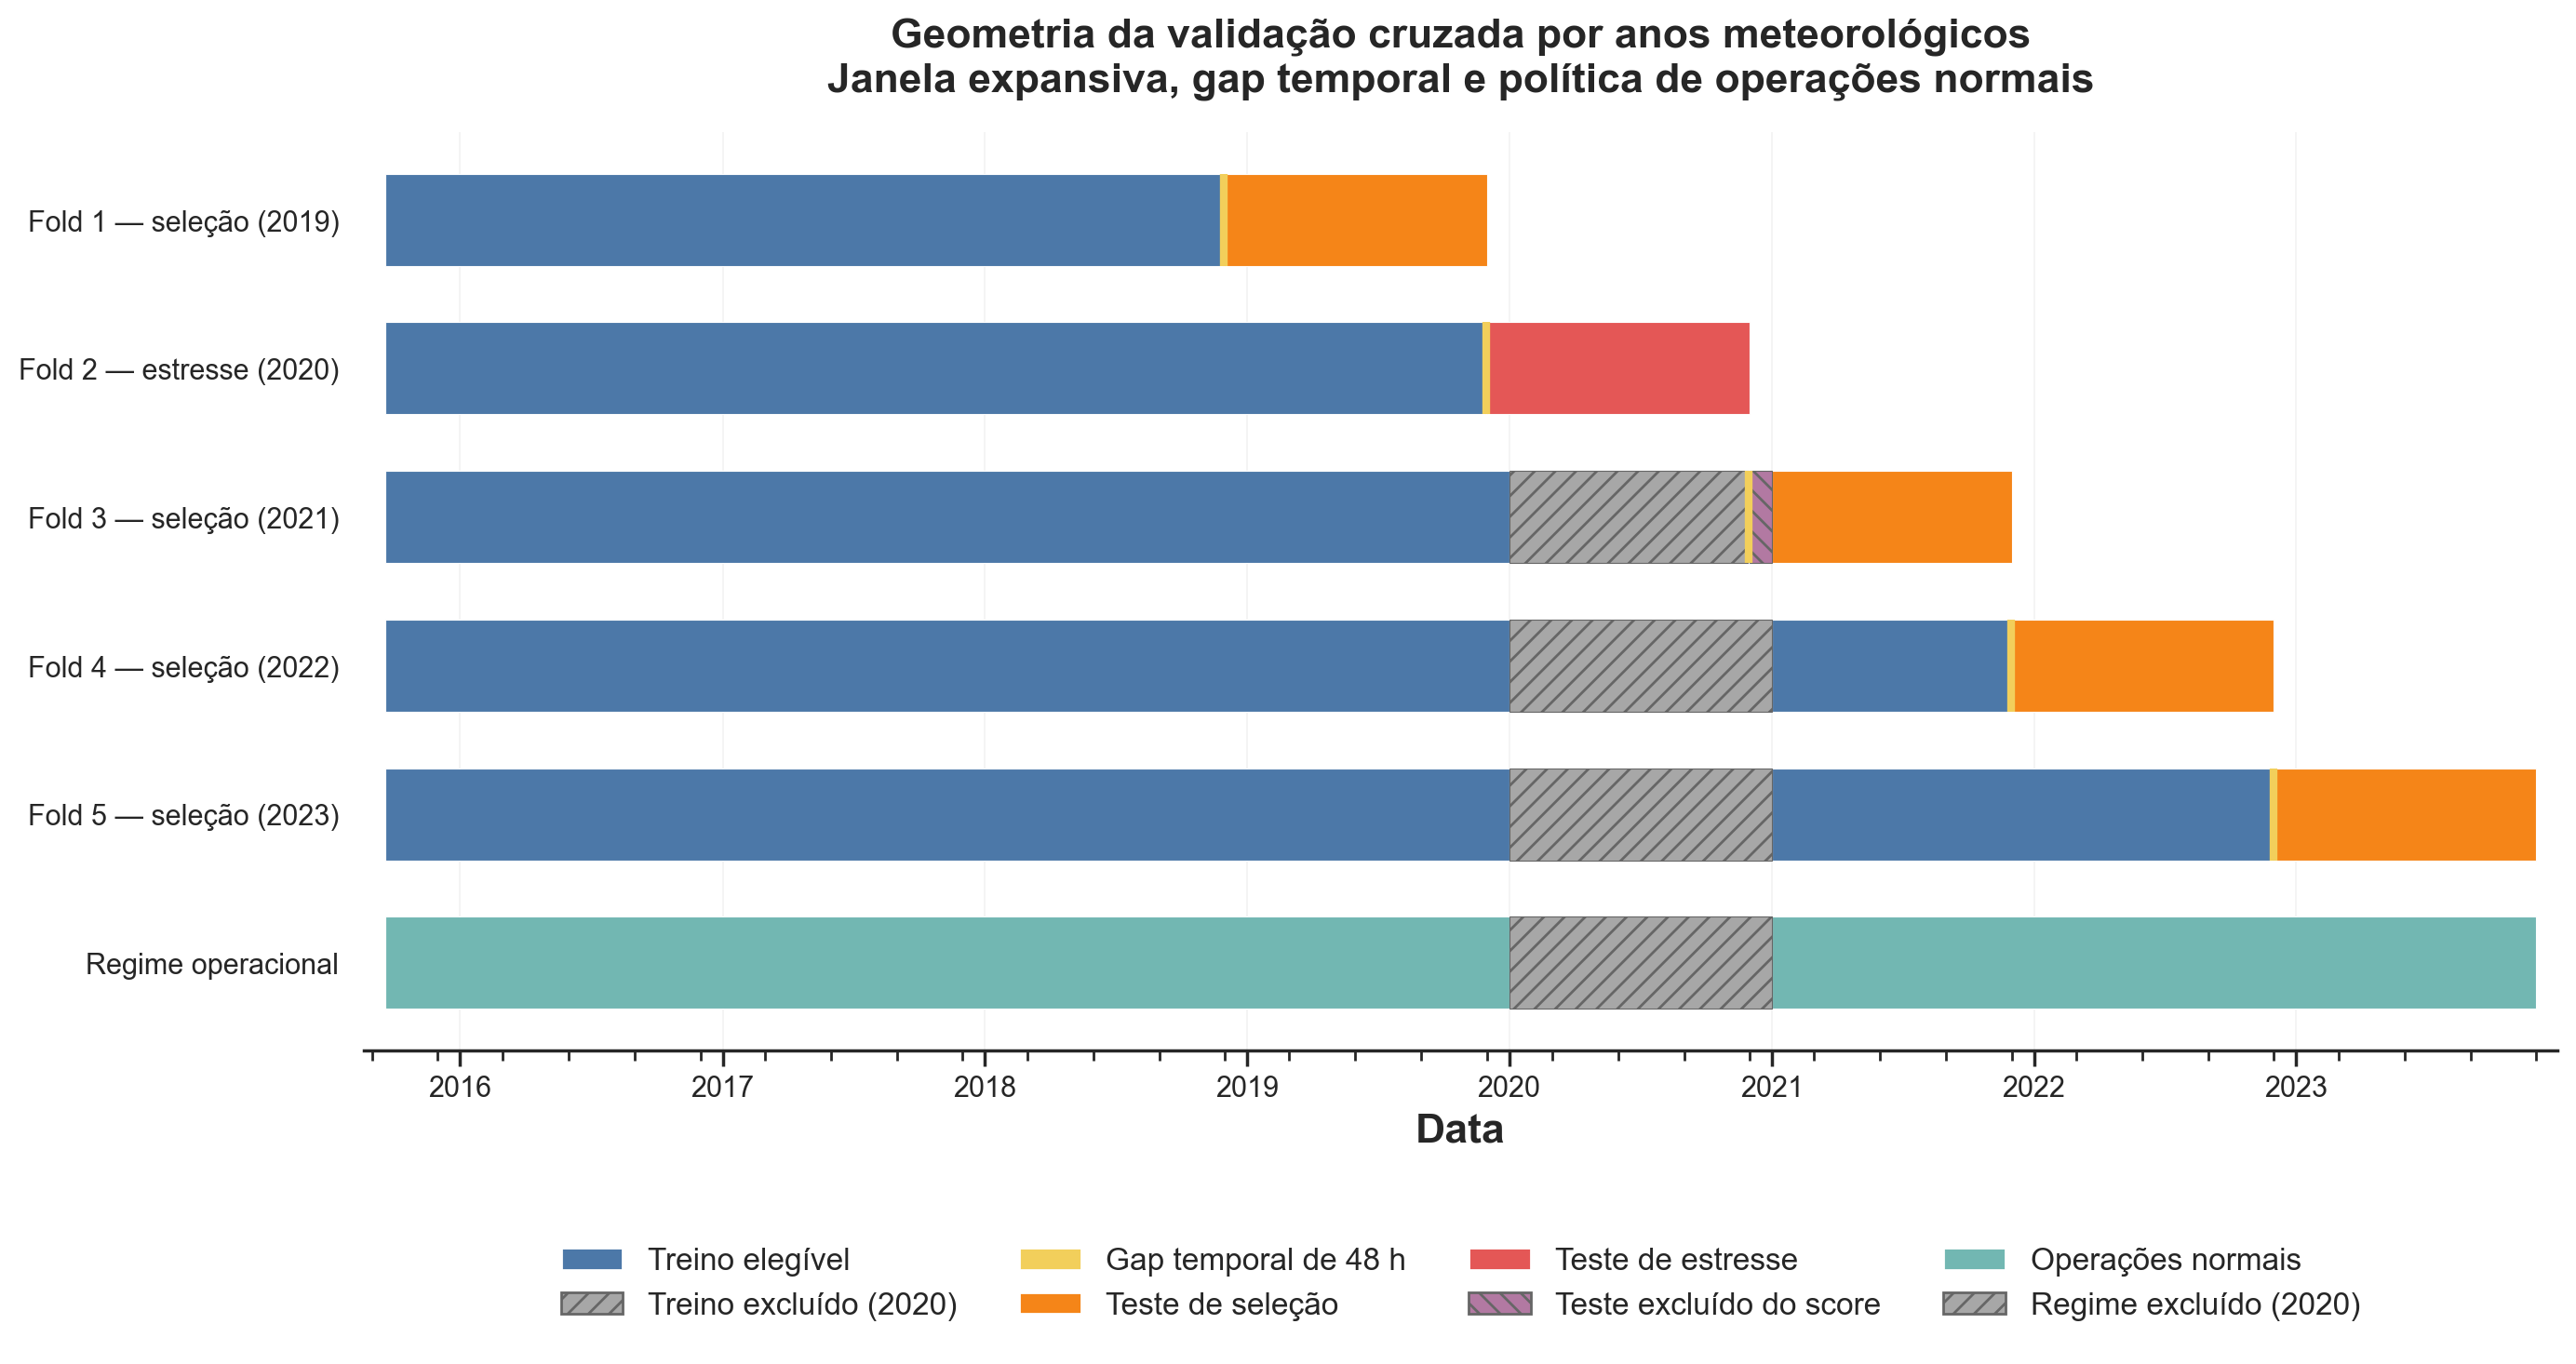

In [6]:
display(reports.fold_audit_report(development, lang=lang))
reports.plot_fold_audit(development, lang=lang)

## 4. Especificação dos experimentos

Cinco ablações controladas são comparadas. Em E0, o Champion atual é reconstruído de forma reprodutível com CatBoost, cuja formulação de boosting ordenado e tratamento de variáveis categóricas foi proposta por Prokhorenkova et al. (2018). Em E1, a hora da semana e interações meteorológicas seletivas são acrescentadas. Em E2, a função `RMSEWithUncertainty` é avaliada como extensão probabilística alinhada à literatura de incerteza em gradient boosting discutida por Malinin, Prokhorenkova e Ustimenko (2021). Em E3, a perda probabilística é combinada com as novas representações. Em E4, a escala residual é ajustada por lags de erros absolutos observáveis sob contrato rolling one-step-ahead.

As novas features são tratadas como exógenas. Como o dataset contém clima observado, a disponibilidade de previsões meteorológicas futuras é assumida como hipótese operacional para eventual produção.

In [7]:
reports.experiment_spec_report(experiment_specs(), lang=lang)

,Experimento,Especificacao,Modelo pontual,Usa hora da semana,Usa interacoes meteorologicas,Usa RMSEWithUncertainty,Usa escala residual,Previsao pontual,Status,Notas
0,E0,Baseline reproduzivel do Champion atual,CatBoostRegressor,Nao,Nao,Nao,Nao,median,planned,
1,E1,Champion com hora da semana e interacoes meteo...,CatBoostRegressor,Sim,Sim,Nao,Nao,median,planned,
2,E2,CatBoost probabilistico sem novas interacoes,CatBoostRegressor,Nao,Nao,Sim,Nao,median,planned,
3,E3,CatBoost probabilistico com interacoes,CatBoostRegressor,Sim,Sim,Sim,Nao,median,planned,
4,E4,Escala residual prequential com lags observaveis,CatBoostRegressor + scale model,Sim,Sim,Sim,Sim,median,planned,


## 5. Baseline reproduzível E0

O E0 serve como controle de sanidade. O mesmo `modeler_name`, encoder, seletor, estratégia de alvo e hiperparâmetros do Champion são lidos do manifesto e reajustados dentro de cada fold de desenvolvimento.

No modo smoke, o número de iterações é reduzido apenas para validar infraestrutura. No modo full, o orçamento registrado no manifesto é preservado, salvo override explícito.

## 6. Hora da semana e interações — E1

A coluna `HourOfWeek` é derivada como `dayofweek * 24 + Hour`, com segunda-feira às 00h igual a 0 e domingo às 23h igual a 167. Para modelos baseados em árvores, essa representação é oferecida como categoria, pois ela permite que combinações específicas de dia e hora sejam separadas sem impor uma relação linear artificial.

As interações meteorológicas são mantidas seletivas. São avaliadas combinações como hora da semana com chuva, hora da semana com faixa de temperatura e período de rush com regime meteorológico, preservando a interpretabilidade e evitando expansão combinatória.

## 7. CatBoost probabilístico — E2

A função `RMSEWithUncertainty` é avaliada por meio de um adaptador dedicado. O método `predict` continua devolvendo uma previsão unidimensional, enquanto `predict_distribution` devolve localização, variância, desvio-padrão e intervalos na escala original da demanda. Essa separação entre ponto e distribuição segue a motivação de previsão probabilística em gradient boosting apresentada por Malinin, Prokhorenkova e Ustimenko (2021) e dialoga com a formulação geral de boosting probabilístico descrita por Duan et al. (2020).

Como o Champion usa decomposição robusta de tendência, a incerteza é modelada sobre o resíduo na escala logarítmica. A mediana da distribuição lognormal é usada como previsão pontual, para manter compatibilidade com o objetivo primário de MAE.

## 8. Interações e incerteza — E3

O E3 combina as hipóteses de E1 e E2. Assim, é avaliado se a estrutura de hora da semana e meteorologia melhora não apenas o valor central, mas também a escala prevista dos intervalos.

Essa comparação é importante porque a heterocedasticidade pode permanecer mesmo quando a média é bem estimada. Por isso, as métricas pontuais e probabilísticas são reportadas separadamente.

## 9. Volatilidade residual prequential — E4

O contrato operacional adotado é rolling one-step-ahead. Ao fim da hora `t`, a demanda real é considerada consolidada antes da previsão para `t+1`, permitindo que o resíduo da hora anterior seja usado sem leakage. A hipótese experimental é motivada pela lógica ARCH de Engle (1982), na qual a variância condicional pode depender de choques passados.

Os lags de 1, 24 e 168 horas são associados por timestamp exato. Durante o cold start, a previsão não é suspensa; a escala probabilística de E3 é usada como fallback e a correção residual é ativada somente quando toda a memória observável amadurece. Após o intervalo operacional excluído, o estado é reiniciado e nenhum resíduo de 2020 pode alimentar a escala prevista em 2021.

In [8]:
results = run_uncertainty_experiments(config, development)

2026-07-31 15:23:18,588 — src.uncertainty_experiments — INFO — Running uncertainty experiment E0
2026-07-31 15:23:42,244 — src.uncertainty_experiments — INFO — Running uncertainty experiment E1
2026-07-31 15:24:09,265 — src.uncertainty_experiments — INFO — Running uncertainty experiment E2
2026-07-31 15:24:39,094 — src.uncertainty_experiments — INFO — Running uncertainty experiment E3


## 10. Comparação pontual

As métricas pontuais são calculadas por fold e agregadas nos folds de seleção sob os pesos de recência já usados no projeto. O MAE ponderado continua sendo a leitura principal para erro absoluto, enquanto R² médio, mediano e ponderado são mantidos para auditar estabilidade.

No modo `full`, os quatro folds normais são usados na comparação principal com os pesos de recência declarados. O fold de 2020 é mantido em uma tabela separada de estresse e não participa do ranking, das métricas probabilísticas nem dos diagnósticos residuais.

,Experimento,Especificacao,Modelo pontual,Usa hora da semana,Usa interacoes meteorologicas,Usa RMSEWithUncertainty,Usa escala residual,Previsao pontual,Status,Notas
0,E0,Baseline reproduzivel do Champion atual,CatBoostRegressor,Nao,Nao,Nao,Nao,median,executed,"{""experiment_id"": ""E0"", ""iterations_override"":..."
1,E1,Champion com hora da semana e interacoes meteo...,CatBoostRegressor,Sim,Sim,Nao,Nao,median,executed,"{""experiment_id"": ""E1"", ""iterations_override"":..."
2,E2,CatBoost probabilistico sem novas interacoes,CatBoostRegressor,Nao,Nao,Sim,Nao,median,executed,"{""experiment_id"": ""E2"", ""iterations_override"":..."
3,E3,CatBoost probabilistico com interacoes,CatBoostRegressor,Sim,Sim,Sim,Nao,median,executed,"{""experiment_id"": ""E3"", ""iterations_override"":..."
4,E4,Escala residual prequential com lags observaveis,CatBoostRegressor + scale model,Sim,Sim,Sim,Sim,median,executed,"{""cold_start_policy"": ""base_or_probabilistic_f..."


,Experimento,MAE medio,MAE ponderado,RMSE medio,R2 medio,R2 mediano,R2 ponderado,WAPE medio,Bias medio,Media do bias absoluto por fold,Desvio-padrao do MAE
0,E0,820.401191,840.165428,1242.845648,0.838691,0.813519,0.857153,0.235199,-400.501401,518.126115,235.514930
1,E3,888.987009,929.471660,1350.334268,0.813802,0.800906,0.829902,0.250732,-455.788471,634.658750,298.552619
2,E4,888.987009,929.471660,1350.334268,0.813802,0.800906,0.829902,0.250732,-455.788471,634.658750,298.552619
3,E1,903.127970,940.308315,1340.587752,0.813502,0.804571,0.829168,0.255896,-485.245045,656.096695,338.259440
4,E2,922.949878,981.579447,1396.453634,0.805831,0.800523,0.817334,0.257975,-408.556510,655.192112,307.768544


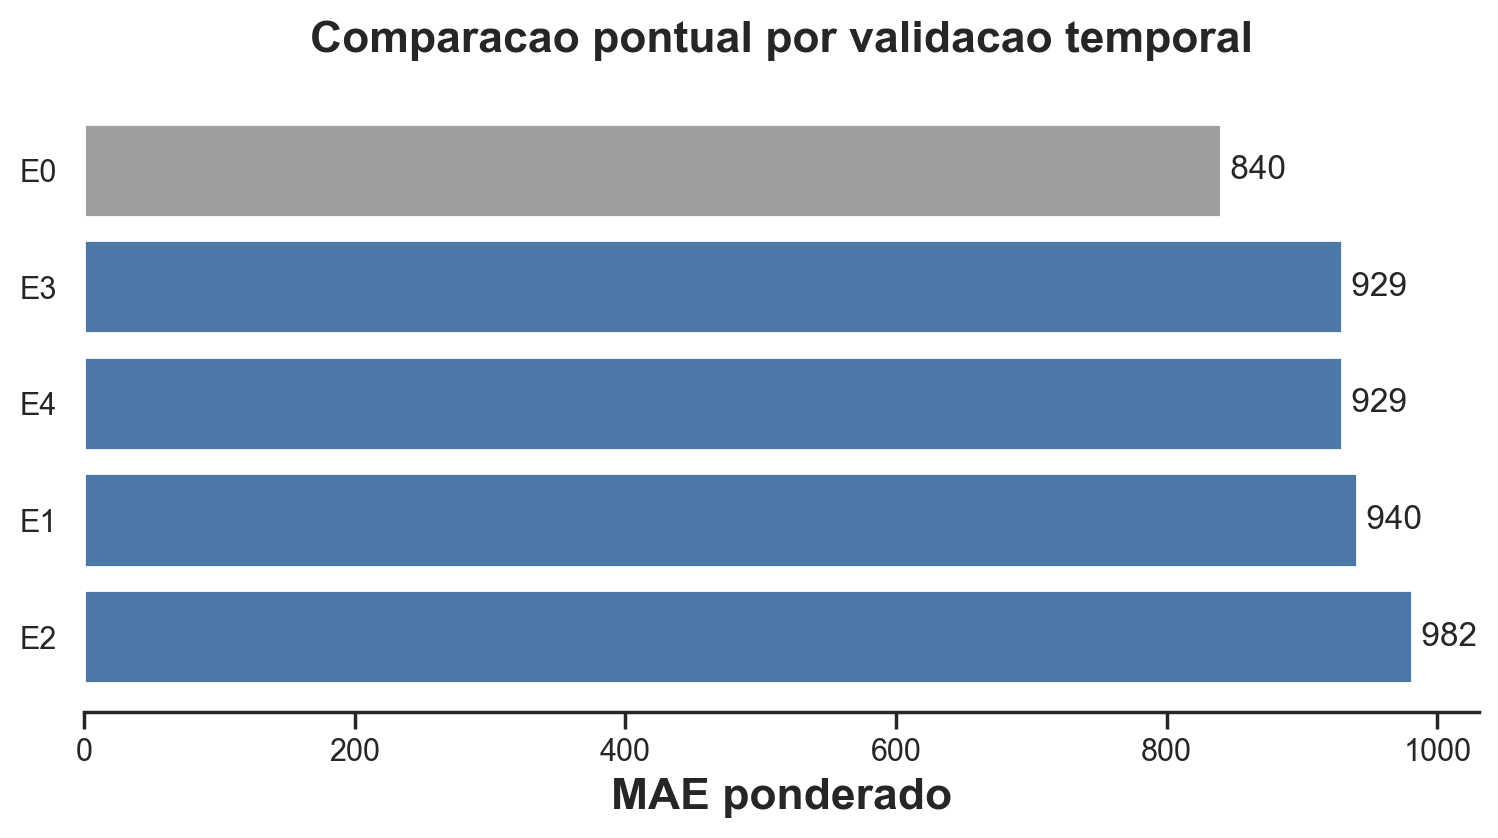

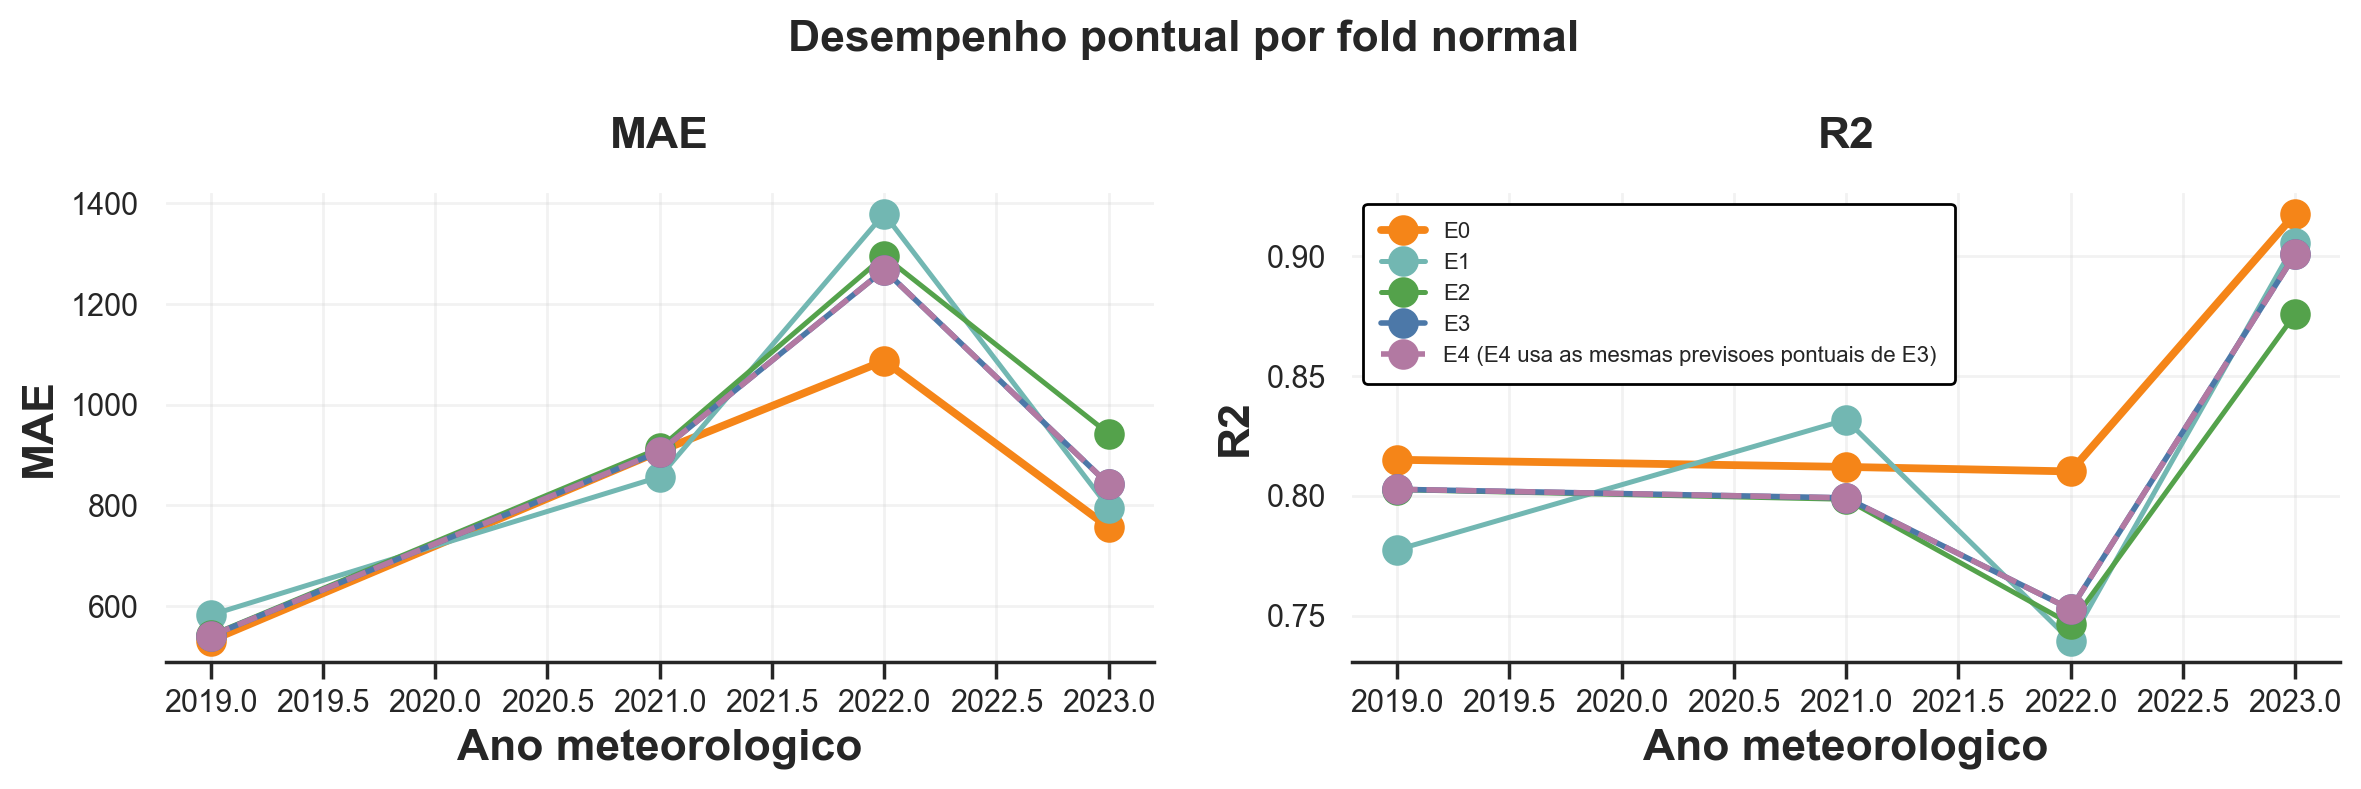

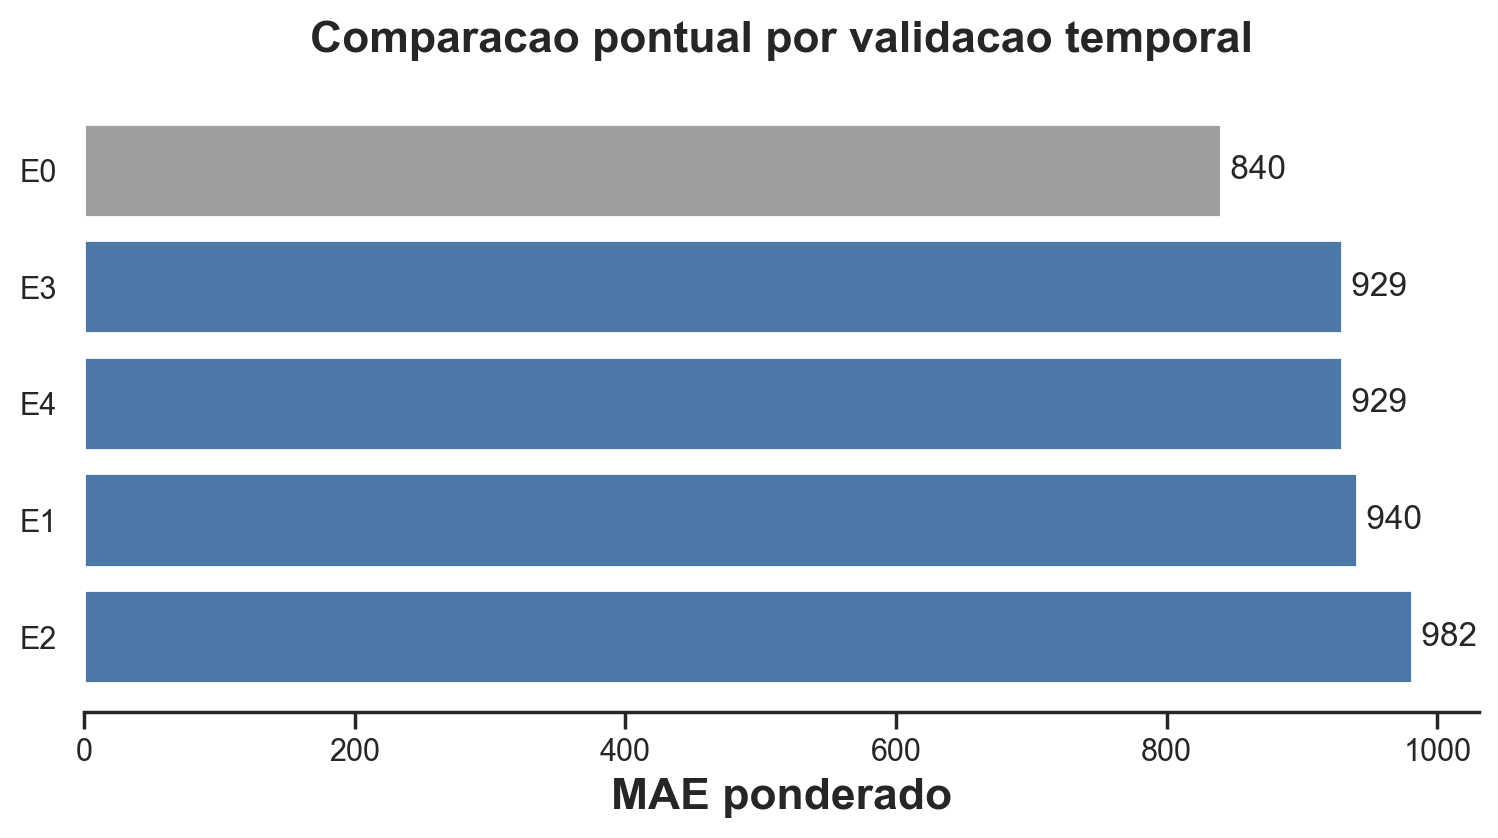

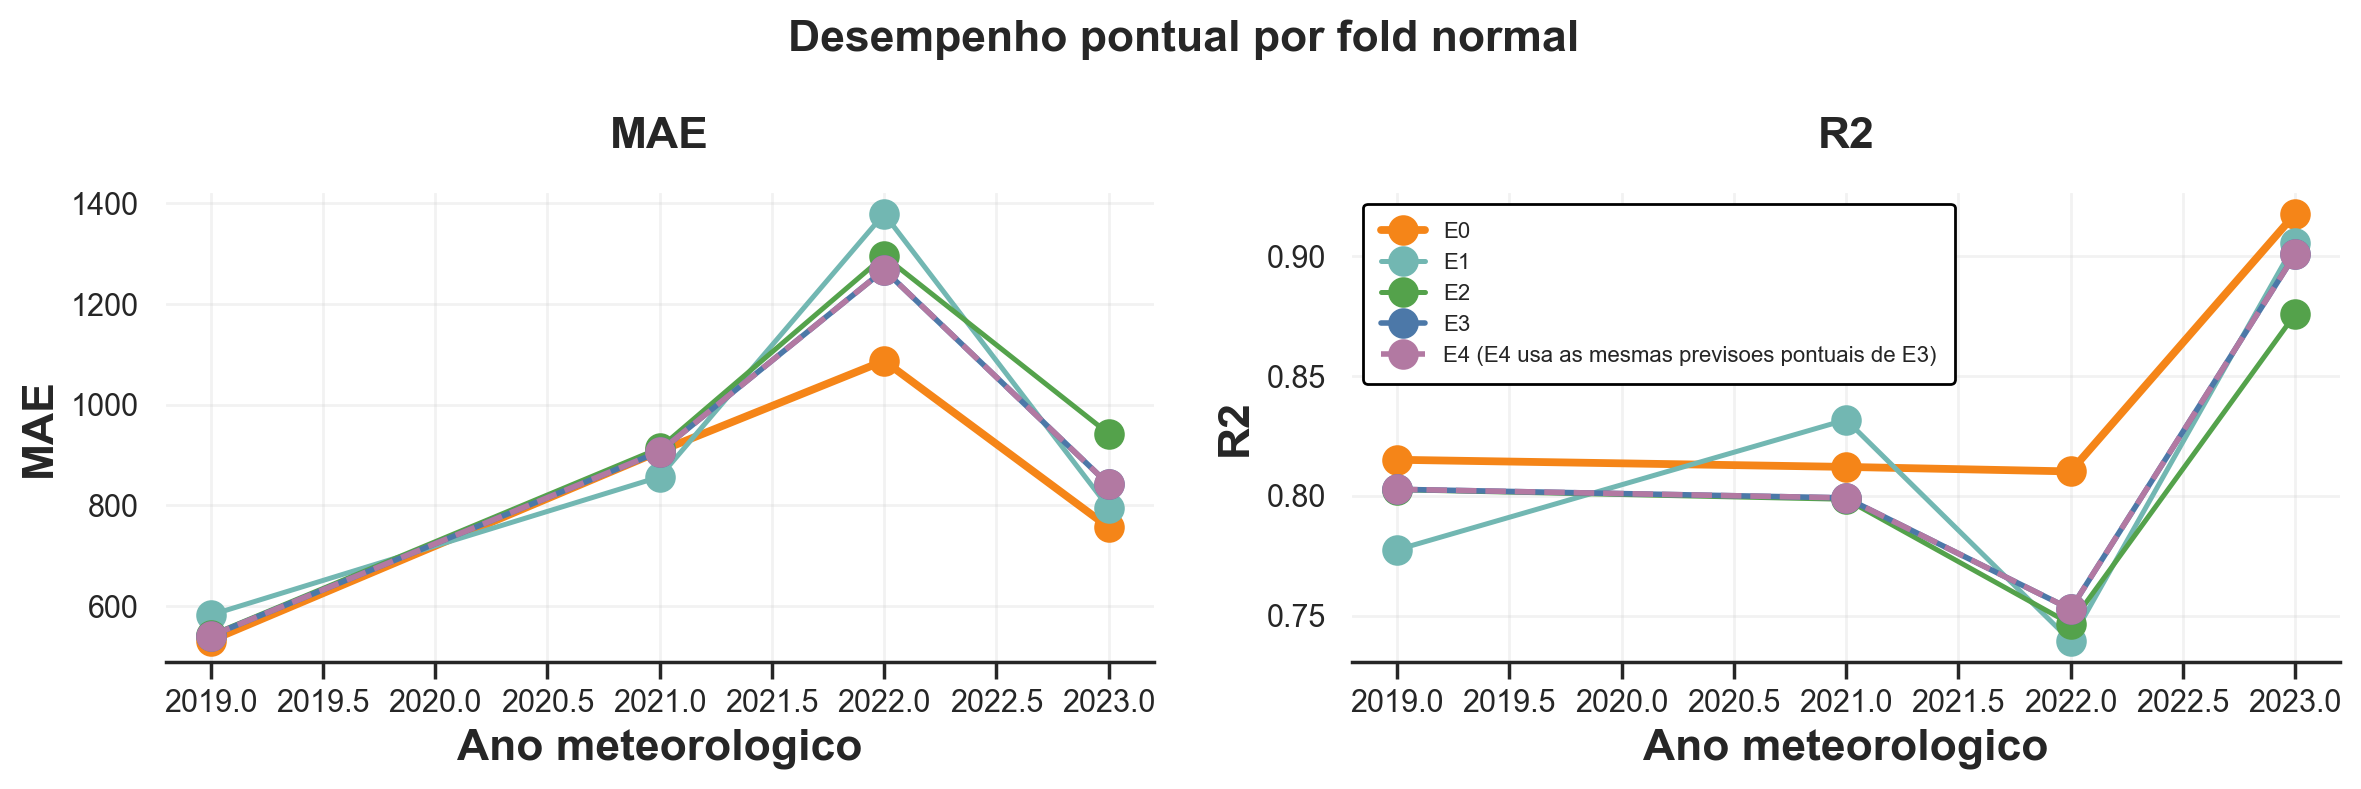

In [9]:
display(reports.experiment_spec_report(results, lang=lang))
display(reports.point_metrics_report(results, lang=lang))
display(reports.plot_point_metrics(results, lang=lang))
reports.plot_point_metrics_by_fold(results, lang=lang)

In [10]:
display(reports.fold_metrics_report(results, lang=lang))
reports.stress_metrics_report(results, lang=lang)

,Experimento,Fold,Ano meteorologico,Linhas de treino,Linhas de treino excluidas,Linhas de teste,Linhas normais pontuadas,MAE de selecao,RMSE de selecao,R2 de selecao,WAPE de selecao,Bias de selecao
0,E0,1,2019,27689.0,0.0,8715,8715,531.067463,782.778501,0.815006,0.261463,-459.828516
2,E0,3,2021,37196.0,7967.0,8760,8016,907.303424,1252.009734,0.812032,0.282839,-481.345596
3,E0,4,2022,45164.0,8759.0,8759,8759,1086.914530,1724.726290,0.810150,0.245017,-896.080920
4,E0,5,2023,53923.0,8759.0,8760,8760,756.319349,1211.868065,0.917577,0.151479,235.249426
5,E1,1,2019,27689.0,0.0,8715,8715,581.901333,858.542982,0.777462,0.286490,-532.359886
7,E1,3,2021,37196.0,7967.0,8760,8016,856.377030,1184.768351,0.831680,0.266963,-472.652127
8,E1,4,2022,45164.0,8759.0,8759,8759,1378.820715,2020.074509,0.739562,0.310820,-1277.671466
9,E1,5,2023,53923.0,8759.0,8760,8760,795.412803,1298.965166,0.905304,0.159309,341.703300
10,E2,1,2019,27689.0,0.0,8715,8715,541.536780,808.742768,0.802530,0.266617,-495.492906
12,E2,3,2021,37196.0,7967.0,8760,8016,913.268540,1296.243549,0.798516,0.284698,-520.334559


,Experimento,Fold,Ano meteorologico,Linhas do diagnostico,MAE de estresse,RMSE de estresse,R2 de estresse,WAPE de estresse,Bias de estresse
1,E0,2,2020,8759,1478.114135,2176.171092,-2.355104,1.418034,1438.243498
6,E1,2,2020,8759,1522.167008,2237.553716,-2.547046,1.460296,1475.998350
11,E2,2,2020,8759,1519.623812,2228.619875,-2.518778,1.457857,1483.605478
16,E3,2,2020,8759,1478.043394,2203.179904,-2.438902,1.417966,1422.685655
21,E4,2,2020,8759,1478.043394,2203.179904,-2.438902,1.417966,1422.685655


## 11. Calibração probabilística

Para E2, E3 e E4, a avaliação deixa de depender apenas do erro pontual. São reportadas a negative log-likelihood na escala logarítmica, a cobertura empírica dos intervalos, a largura média e o Winkler score. A leitura segue a distinção entre calibração, sharpness e regras de pontuação próprias discutida por Gneiting, Balabdaoui e Raftery (2007) e por Gneiting e Raftery (2007).

Um modelo pode reduzir a estatística ARCH e ainda assim produzir intervalos mal calibrados. Por esse motivo, a cobertura nominal versus observada é tratada como diagnóstico próprio.

,Experimento,Observacoes,Negative log-likelihood,Largura media do intervalo 90%
0,E2,34250,1.043336,16660.557816
1,E3,34250,1.042262,16432.449429
2,E4,34250,0.945993,4501.534303


,Experimento,Cobertura nominal,Cobertura observada,Erro de calibracao,Largura media,Winkler score
0,E2,0.50,0.892321,0.392321,4817.252538,5017.439425
1,E2,0.80,0.987182,0.187182,11066.014385,11110.072618
2,E2,0.90,0.995562,0.095562,16660.557816,16688.130766
3,E2,0.95,0.997693,0.047693,23331.311183,23352.348683
4,E3,0.50,0.893577,0.393577,4748.895505,4948.652082
5,E3,0.80,0.985927,0.185927,10911.653997,10963.304497
6,E3,0.90,0.994599,0.094599,16432.449429,16472.370015
7,E3,0.95,0.997606,0.047606,23020.183090,23057.495215
8,E4,0.50,0.518920,0.018920,1576.342833,3059.536707
9,E4,0.80,0.724350,-0.075650,3252.445473,4988.585930


,Experimento,Fold,Ano meteorologico,Cobertura nominal,Cobertura observada,Erro de calibracao,Largura media,Winkler score,Observacoes
0,E2,1,2019,0.50,0.929317,0.429317,2261.643045,2351.599886,8715
4,E2,3,2021,0.50,0.833084,0.333084,3955.750789,4165.942031,8016
8,E2,4,2022,0.50,0.843818,0.343818,4900.719703,5298.950936,8759
12,E2,5,2023,0.50,0.958219,0.458219,8064.609370,8167.283646,8760
16,E3,1,2019,0.50,0.930924,0.430924,2260.530626,2350.453521,8715
20,E3,3,2021,0.50,0.822106,0.322106,3954.630839,4189.096888,8016
24,E3,4,2022,0.50,0.856947,0.356947,4821.584872,5204.092667,8759
28,E3,5,2023,0.50,0.958447,0.458447,7878.603189,7973.137335,8760
32,E4,1,2019,0.50,0.930924,0.430924,2260.530626,2350.453521,8715
36,E4,3,2021,0.50,0.269586,-0.230414,959.926462,2935.335207,8016


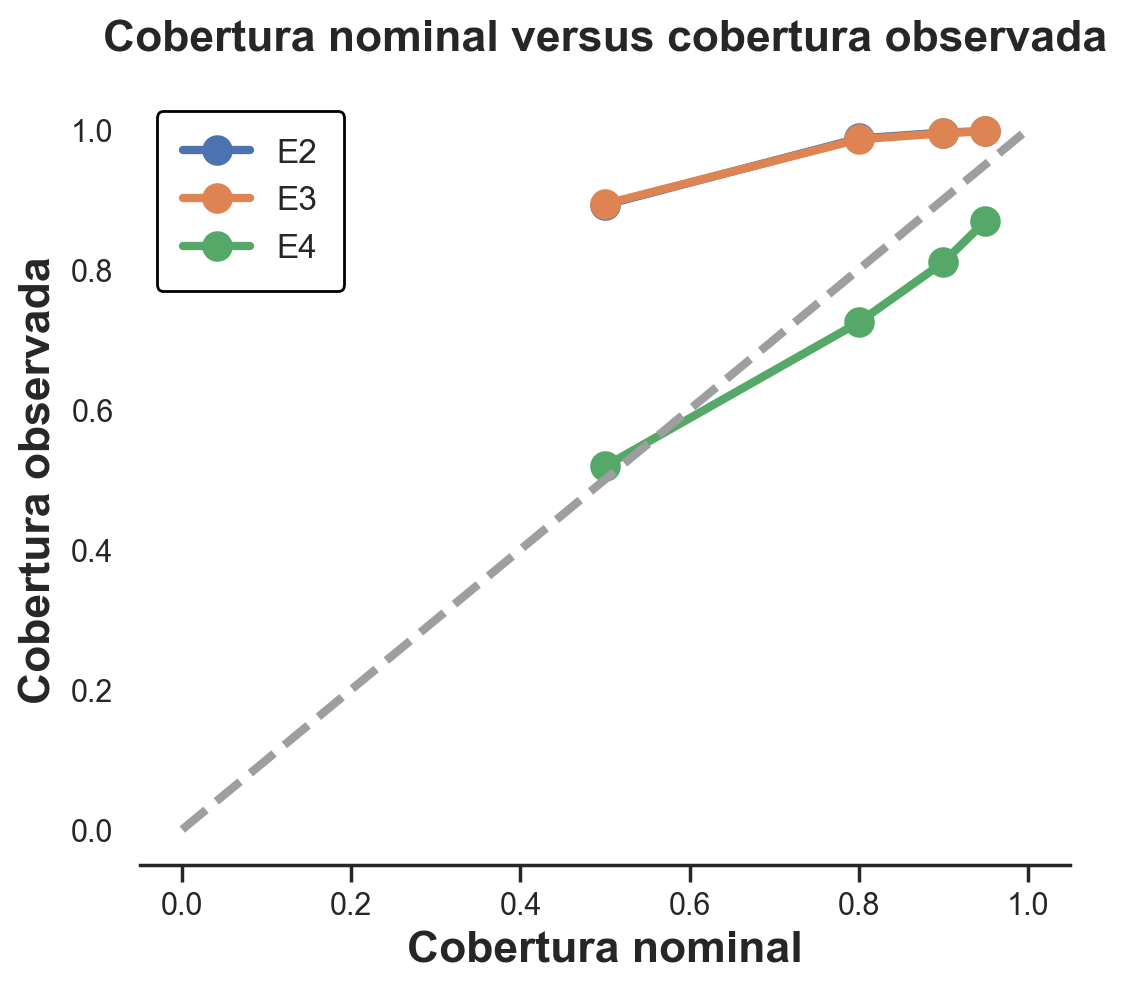

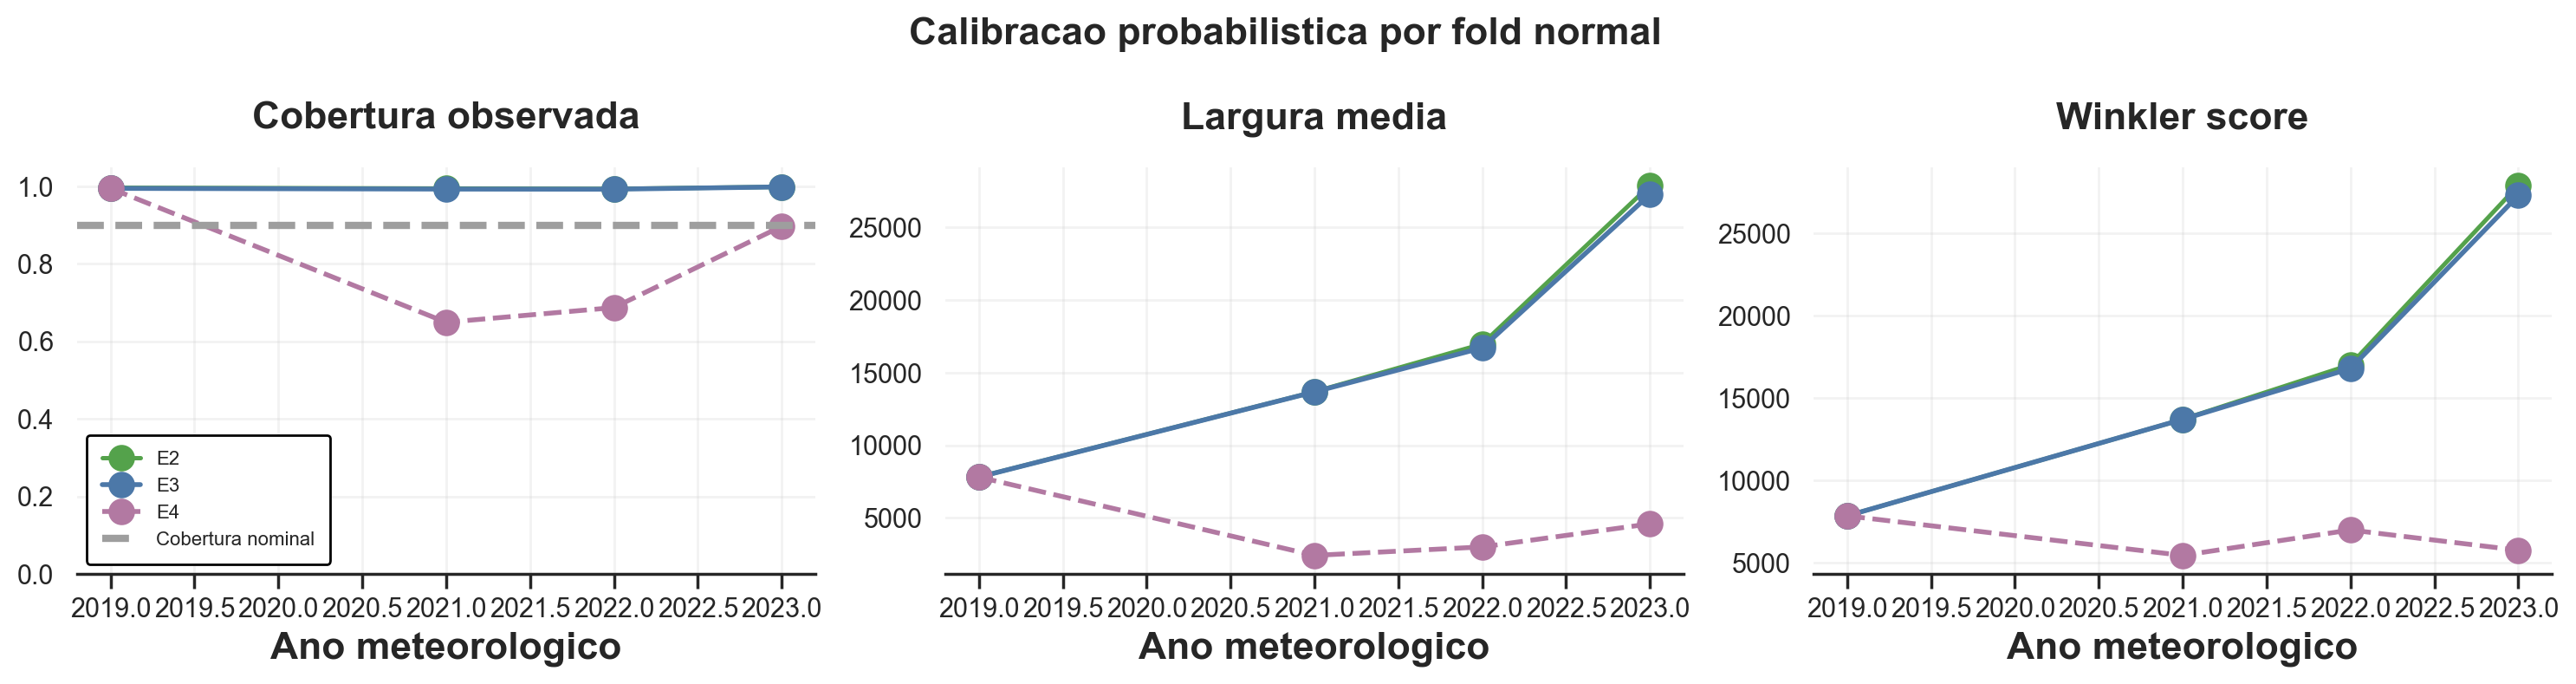

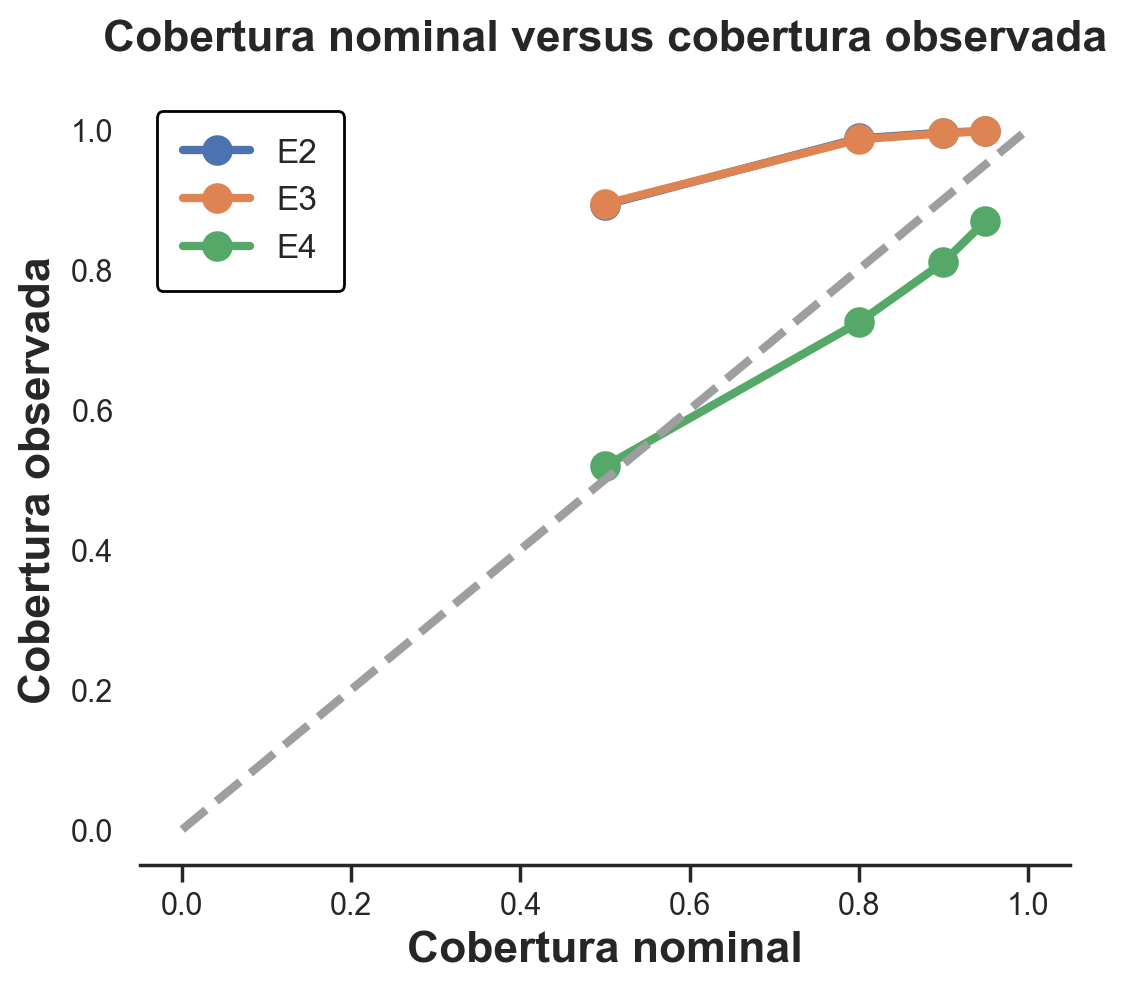

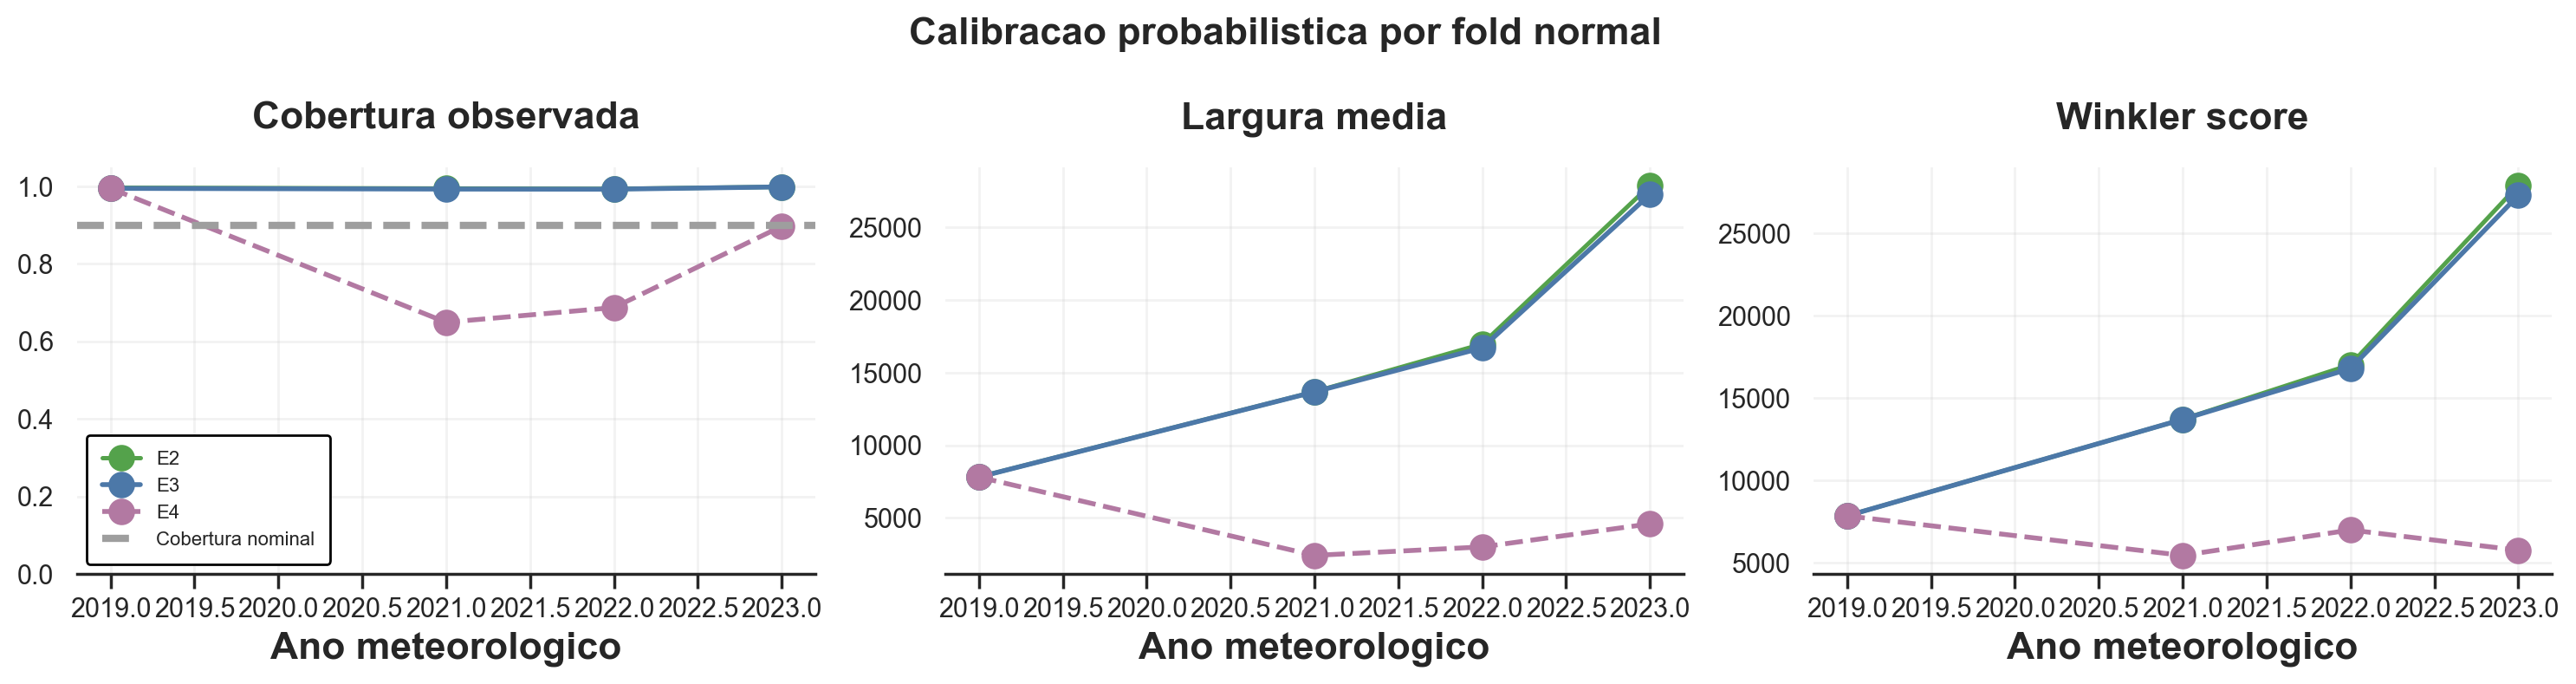

In [11]:
display(reports.probabilistic_metrics_report(results, lang=lang))
display(reports.interval_metrics_report(results, lang=lang))
display(reports.probabilistic_fold_metrics_report(results, lang=lang))
display(reports.plot_coverage_calibration(results, lang=lang))
reports.plot_probabilistic_metrics_by_fold(results, coverage=0.90, lang=lang)

,Experimento,segment,Decil da demanda prevista,Observacoes,MAE,rmse,r2,wape,mean_bias,Cobertura 90%,Largura media 90%
56,E2,predicted_demand_decile,0,3425,172.802682,351.051150,-0.016870,0.497707,-115.523809,0.976934,1366.535993
57,E2,predicted_demand_decile,1,3425,273.969805,469.397242,-0.093591,0.403249,-165.768845,0.994161,2840.213754
58,E2,predicted_demand_decile,2,3425,367.802365,554.145723,-0.088574,0.360332,-195.377194,0.994453,4398.516008
59,E2,predicted_demand_decile,3,3425,571.914809,828.577554,-0.148250,0.356820,-350.018477,0.996496,6550.473525
60,E2,predicted_demand_decile,4,3425,737.253272,1015.070022,-0.216458,0.323509,-481.764048,0.997956,9270.731527
61,E2,predicted_demand_decile,5,3425,963.381682,1293.890952,-0.274222,0.309256,-646.343832,0.998832,12640.728540
62,E2,predicted_demand_decile,6,3425,1212.030128,1635.134257,-0.235910,0.290244,-795.732160,0.999416,17209.024116
63,E2,predicted_demand_decile,7,3425,1341.056944,1804.981555,-0.223974,0.247536,-866.899923,0.999708,23066.390013
64,E2,predicted_demand_decile,8,3425,1562.862378,2130.191199,-0.057312,0.217351,-758.284915,0.998248,32498.427362
65,E2,predicted_demand_decile,9,3425,2033.430475,2627.739201,0.425228,0.185487,315.776746,0.999416,56764.537324


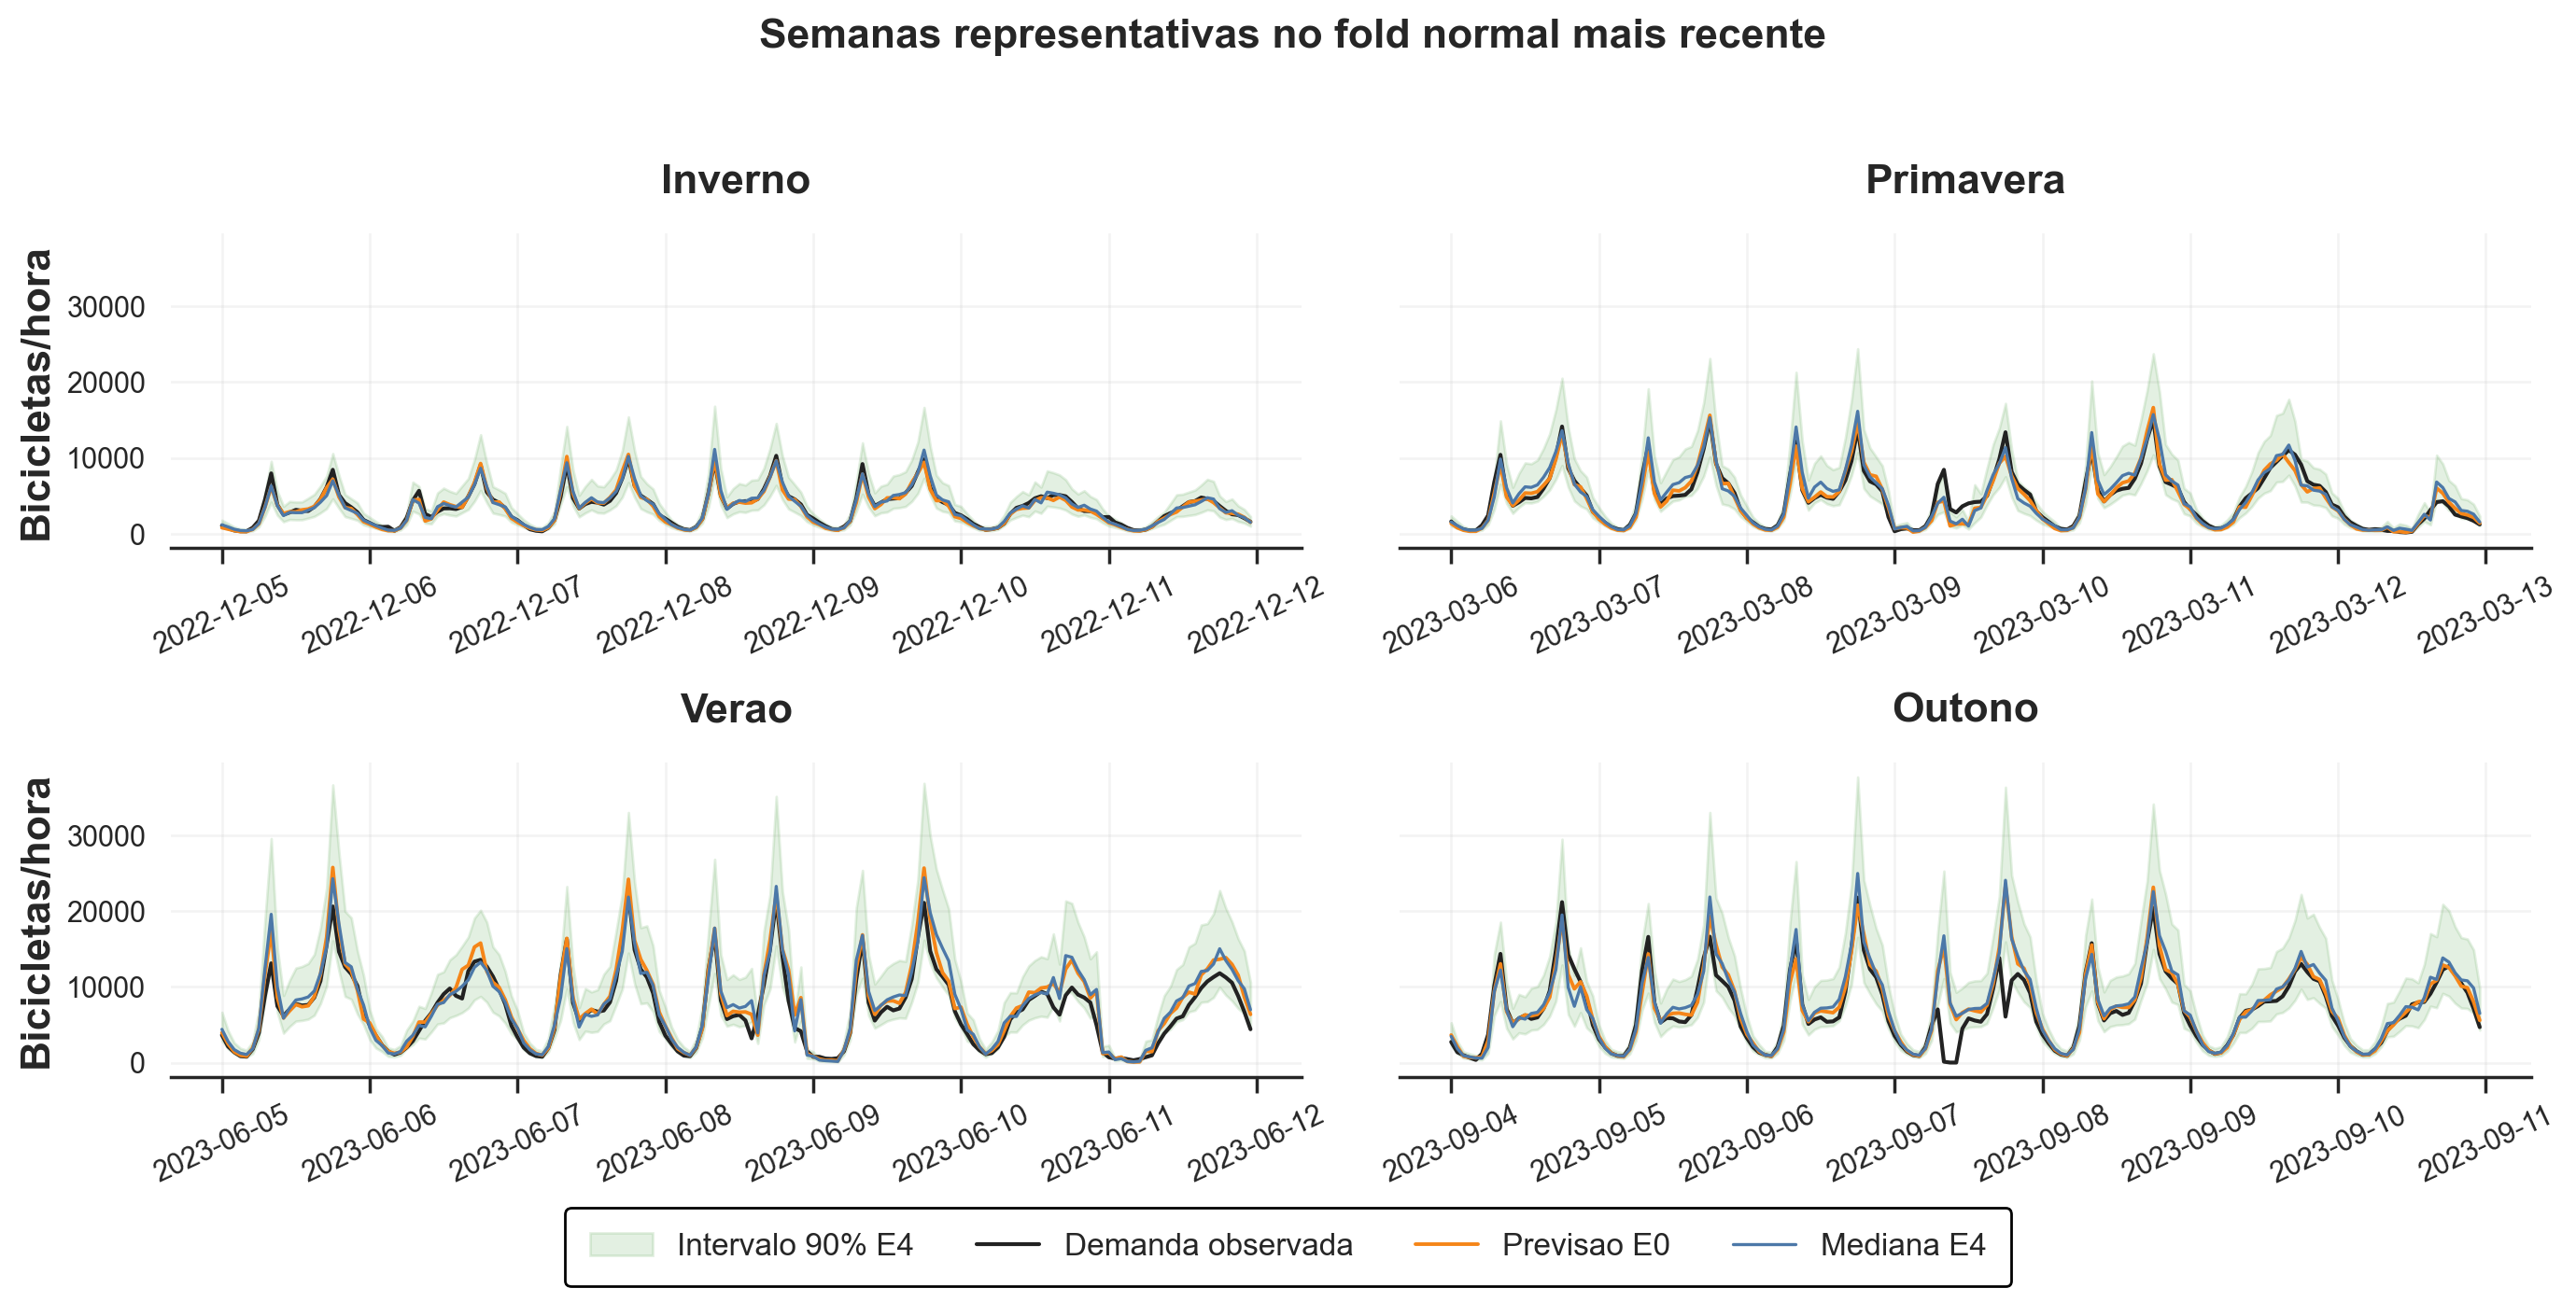

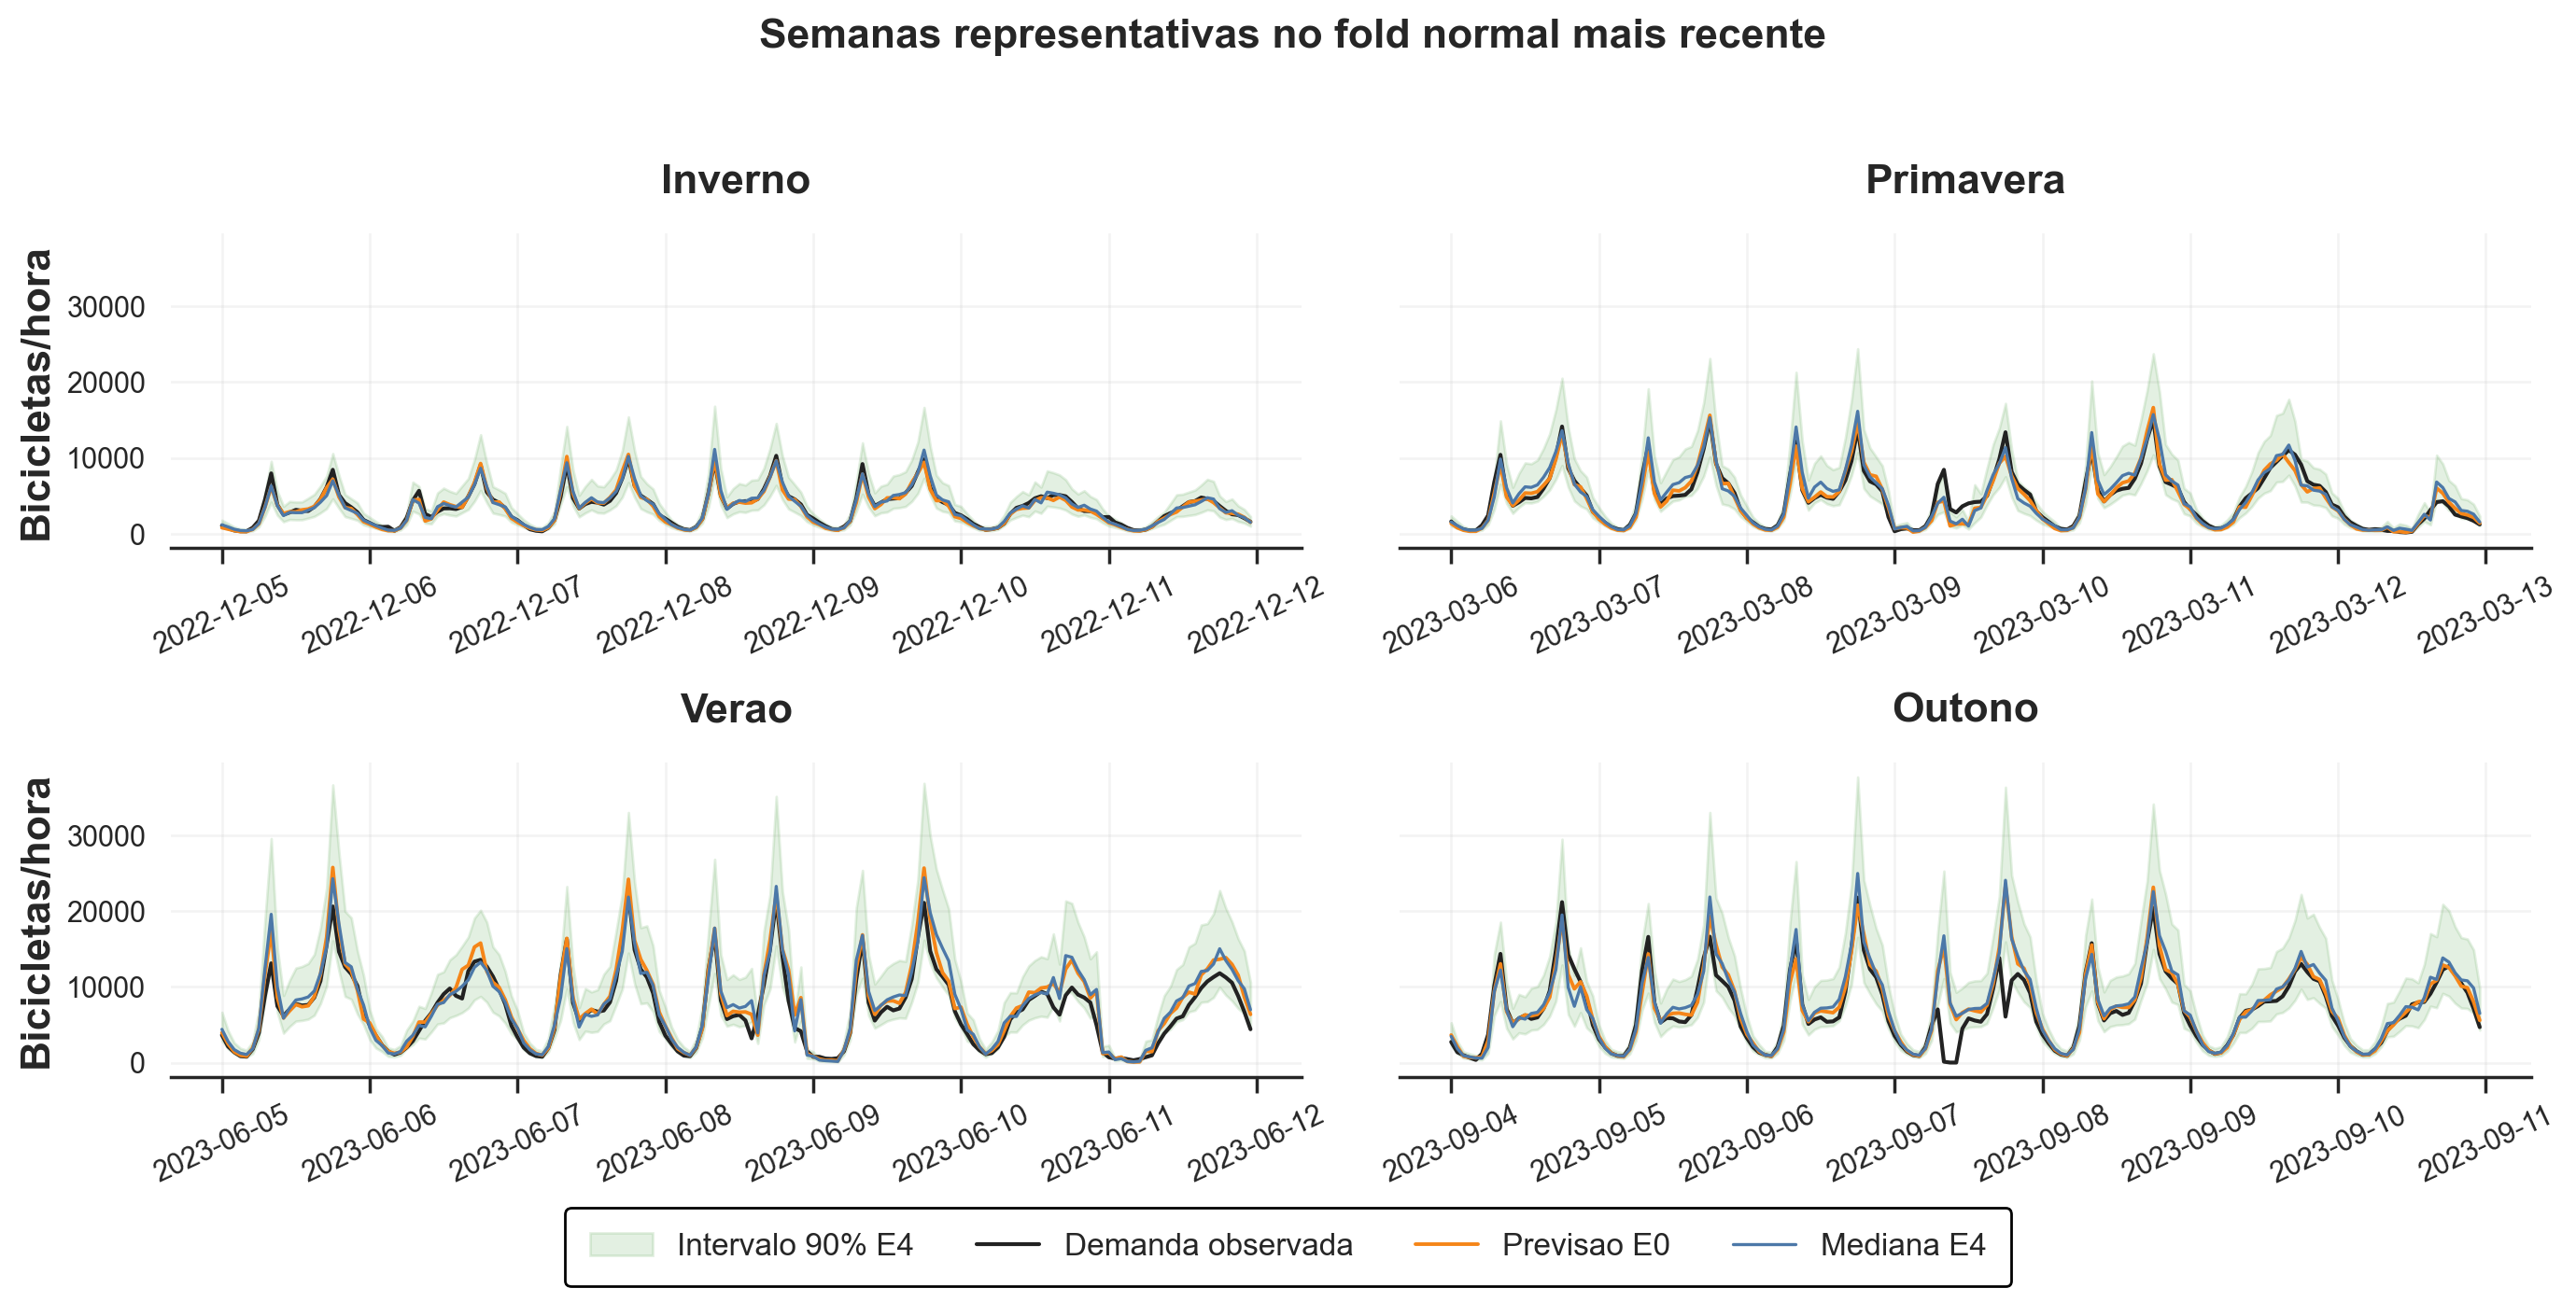

In [12]:
display(reports.interval_width_report(results, lang=lang))
reports.plot_representative_interval_windows(results, lang=lang)

## 12. Ablação e estabilidade

A estrutura residual é auditada por autocorrelação dos resíduos, autocorrelação dos resíduos quadráticos e estatística ARCH normalizada por observação. Essas medidas não substituem MAE e R², mas indicam se a variância condicional continua concentrada no tempo, como no problema clássico de heterocedasticidade condicional formalizado por Engle (1982).

A ablação compara E1, E2 e E3 contra E0, e compara E4 contra E3. Dessa forma, o efeito das features, da loss probabilística e da escala residual é separado.

,Experimento,Observacoes,ACF residual lag 1,ACF residual quadratico lag 1,ACF residual lag 24,ACF residual quadratico lag 24,ACF residual lag 168,ACF residual quadratico lag 168,ARCH por observacao lag 24,ARCH por observacao lag 168
0,E0,34250,0.783941,0.517433,0.625628,0.484679,0.595075,0.501808,0.432036,0.508025
1,E1,34250,0.793152,0.541511,0.656899,0.511233,0.637579,0.507858,0.469560,0.542626
2,E2,34250,0.791136,0.558395,0.650768,0.502358,0.636992,0.520401,0.463573,0.538801
3,E3,34250,0.761792,0.533954,0.623615,0.495378,0.623066,0.529567,0.451833,0.534388
4,E4,34250,0.761792,0.533954,0.623615,0.495378,0.623066,0.529567,0.451833,0.534388


,Experimento,Fold,Ano meteorologico,Observacoes,Taxa de fallback,Taxa no piso,P10,P25,Mediana,P75,P90
0,E4,1,2019,8715,1.000000,0.000000,1.00,1.00,1.00,1.000000,1.000000
1,E4,3,2021,8016,0.020958,0.819736,0.25,0.25,0.25,0.250000,0.296377
2,E4,4,2022,8759,0.000343,0.732504,0.25,0.25,0.25,0.258335,0.360567
3,E4,5,2023,8760,0.000000,0.972717,0.25,0.25,0.25,0.250000,0.250000


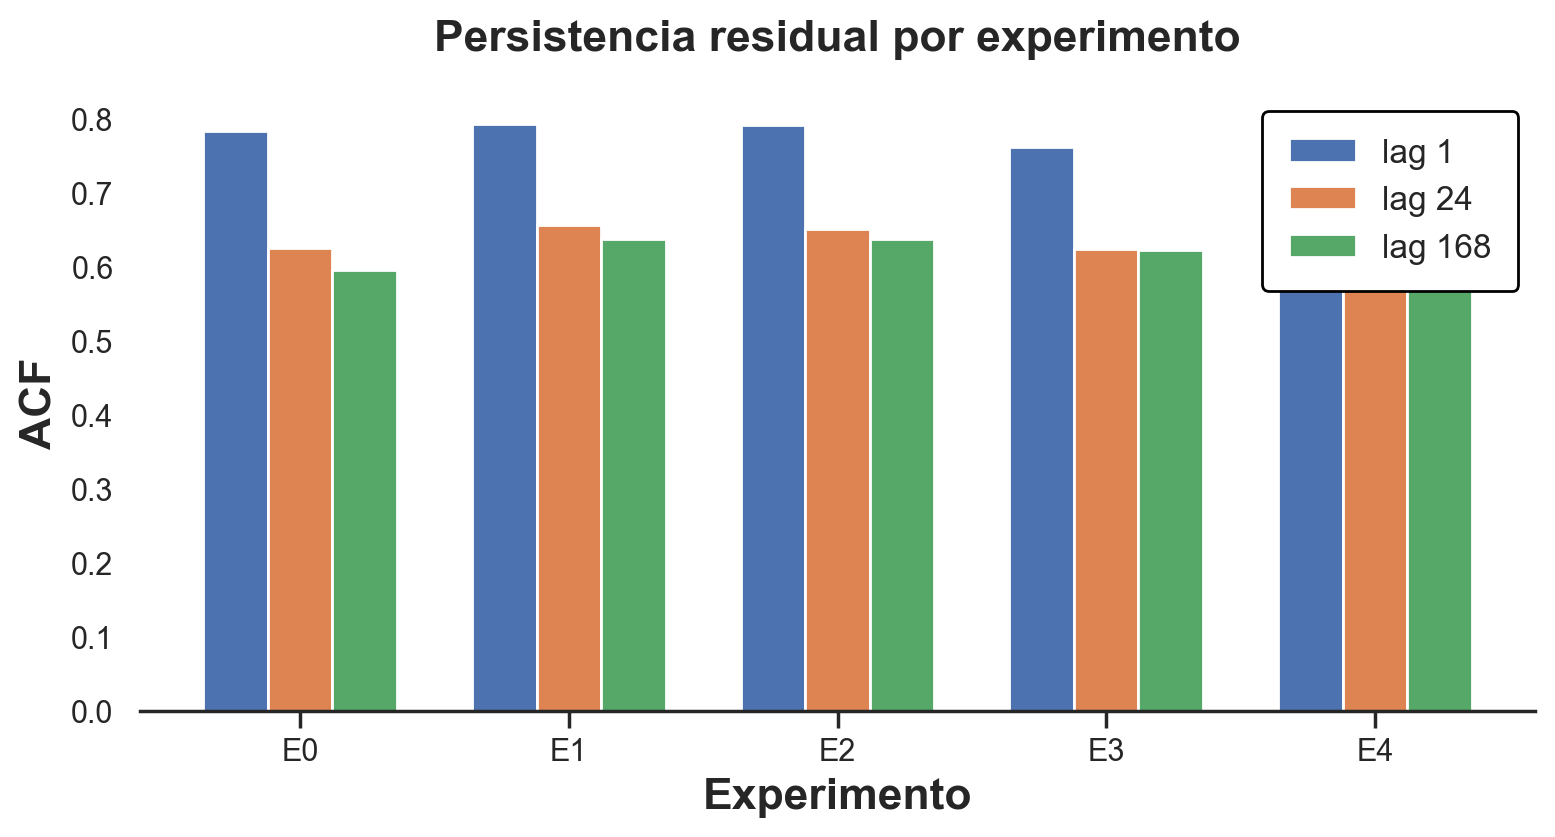

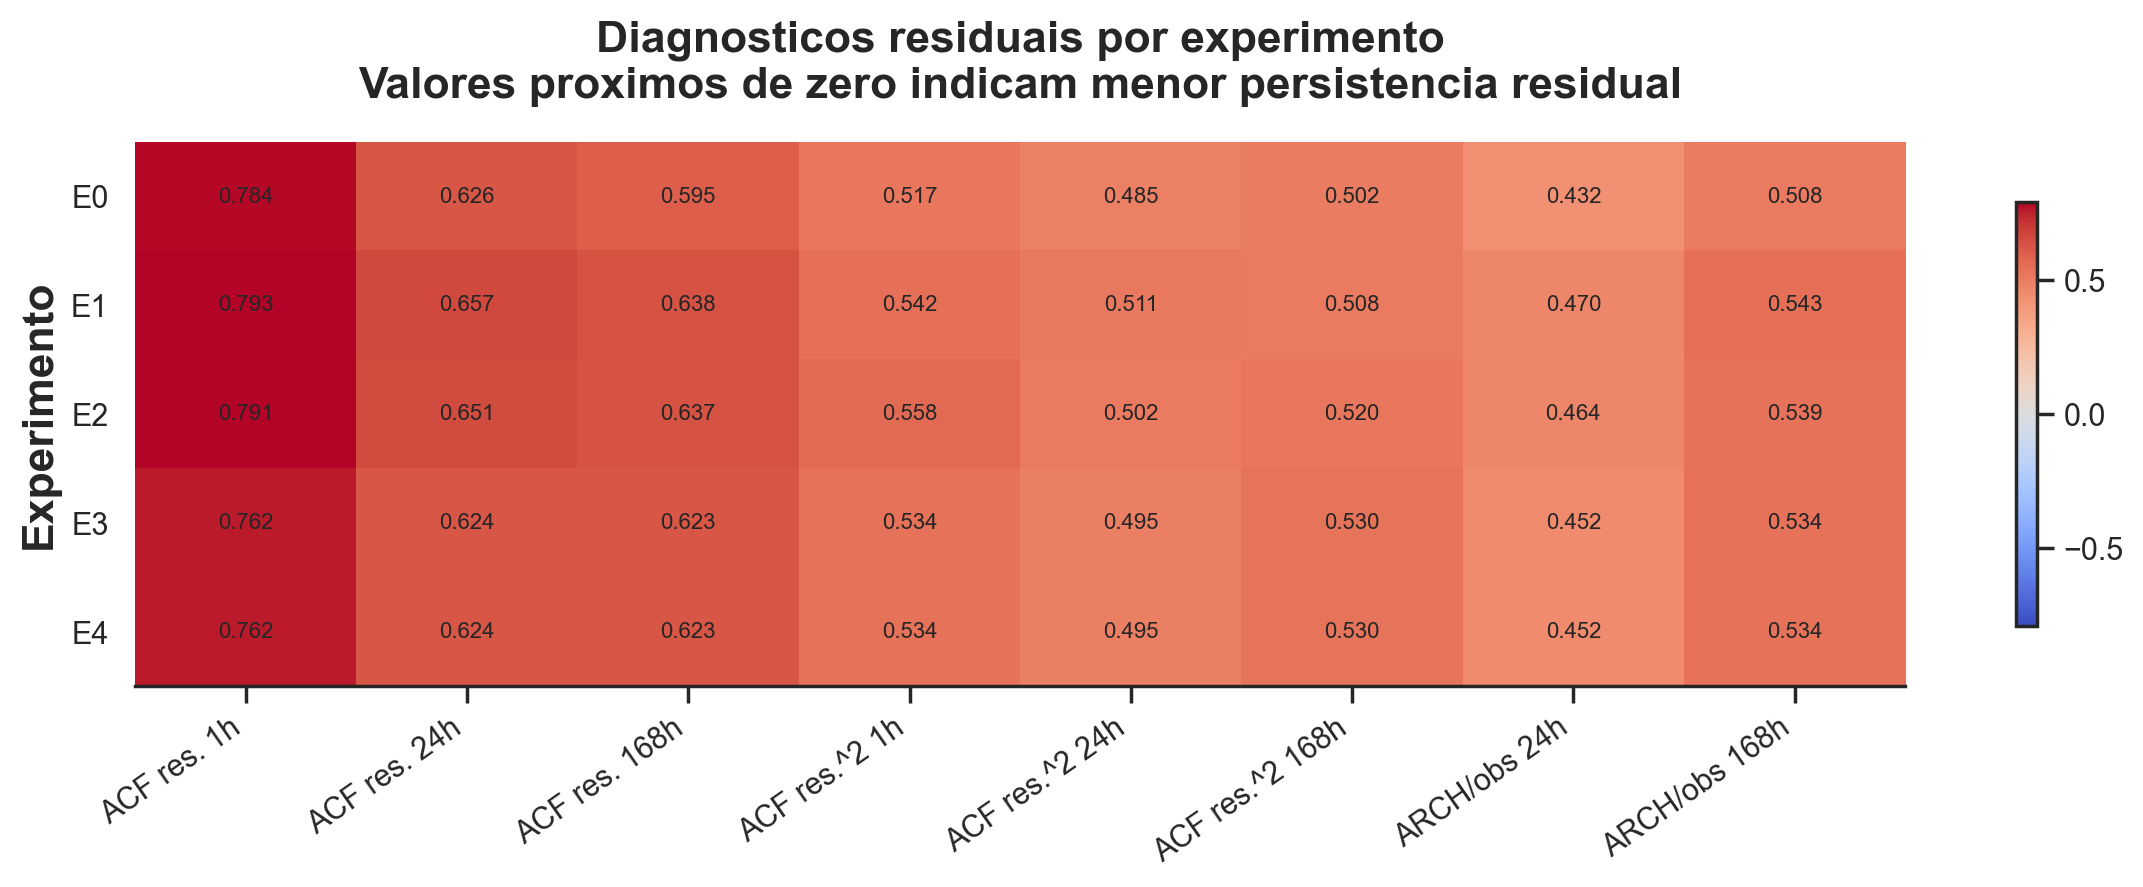

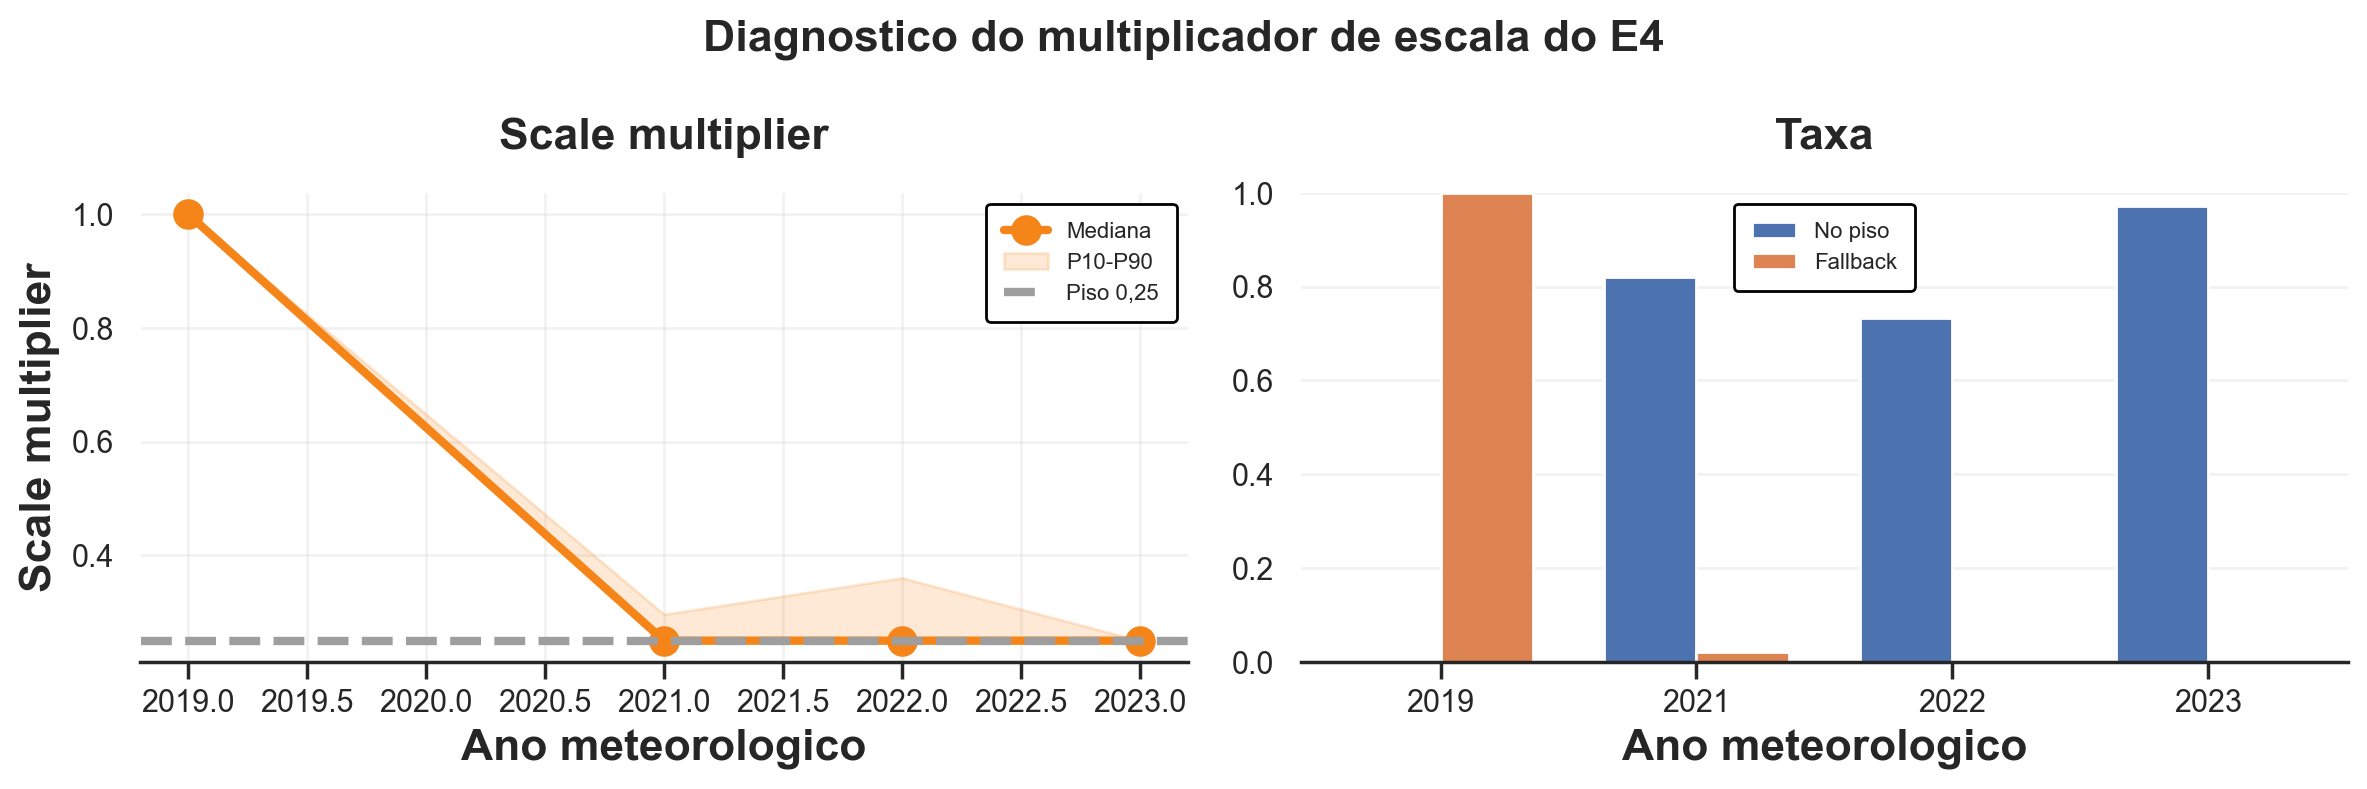

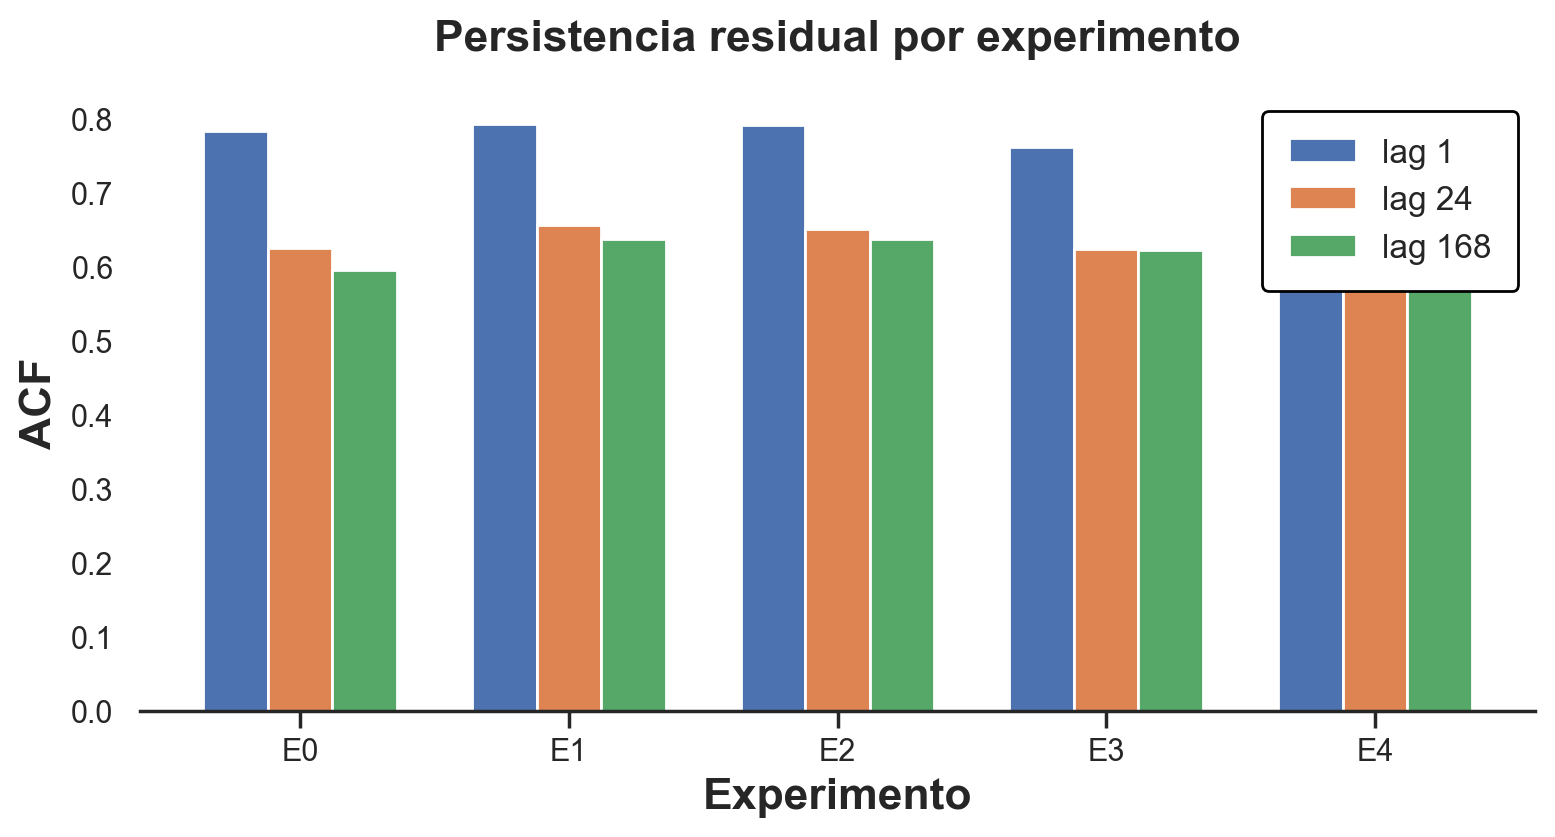

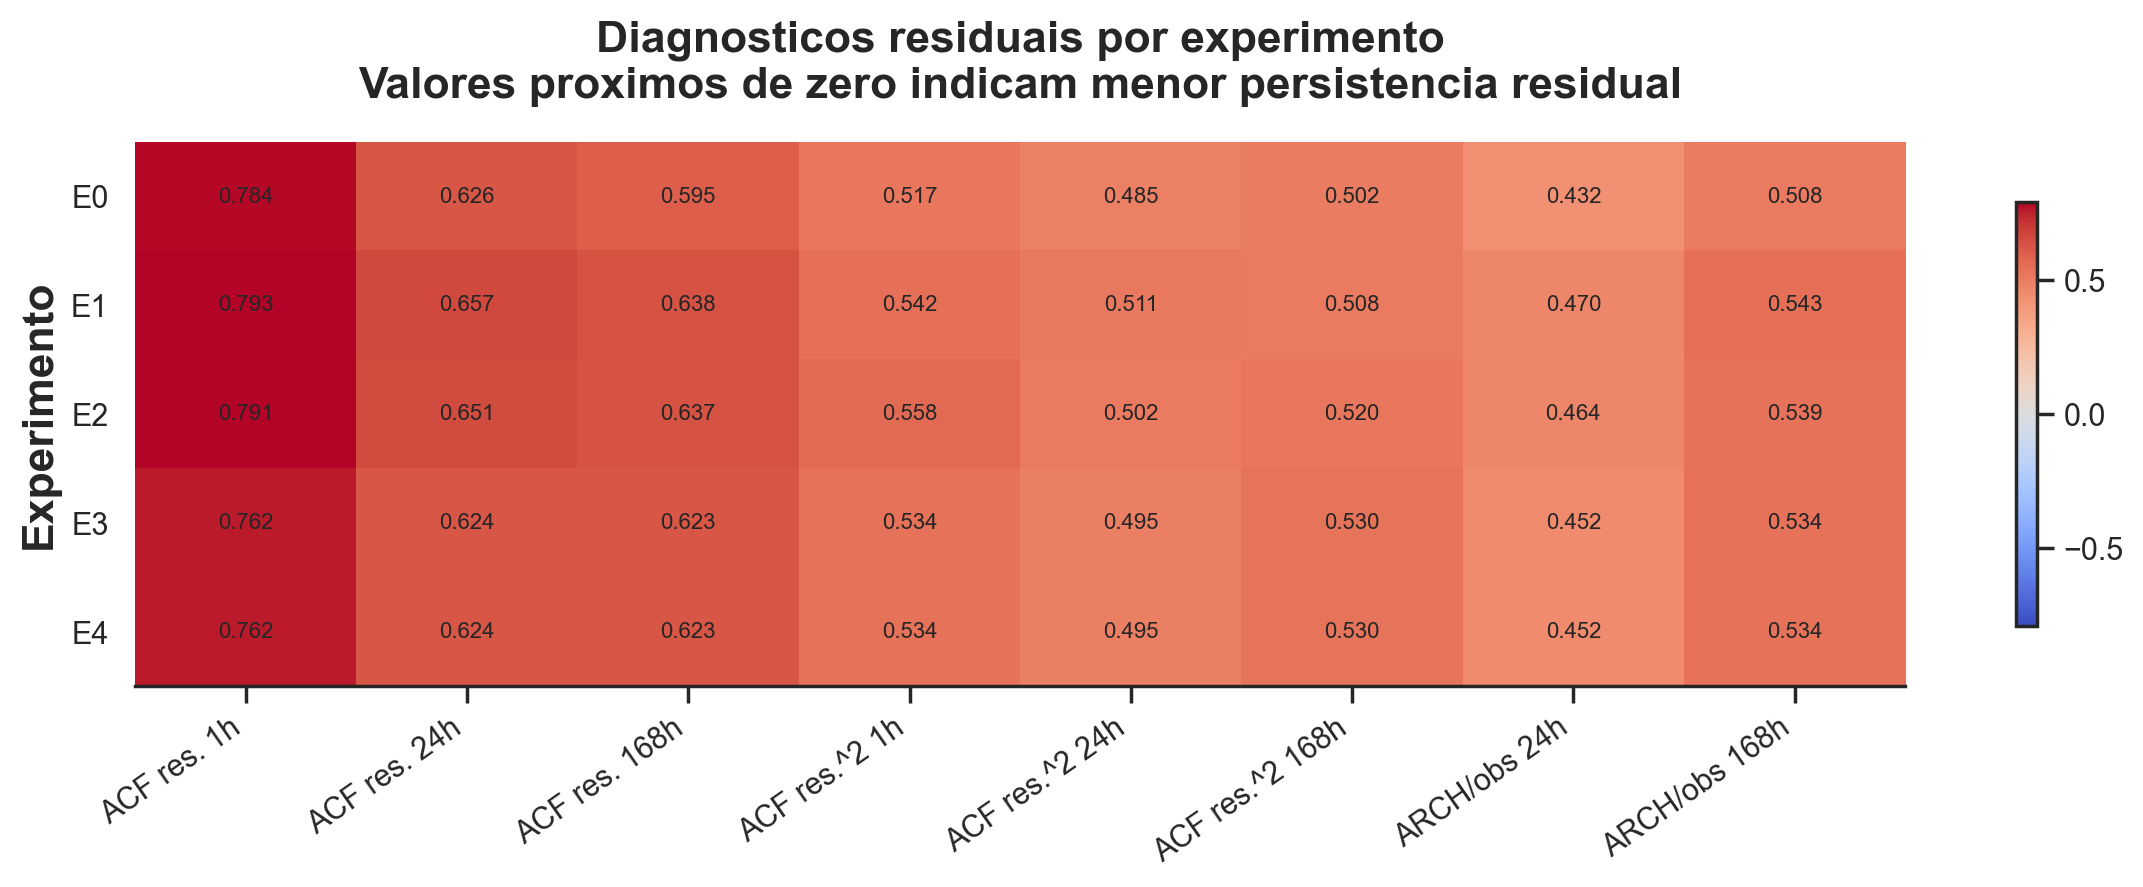

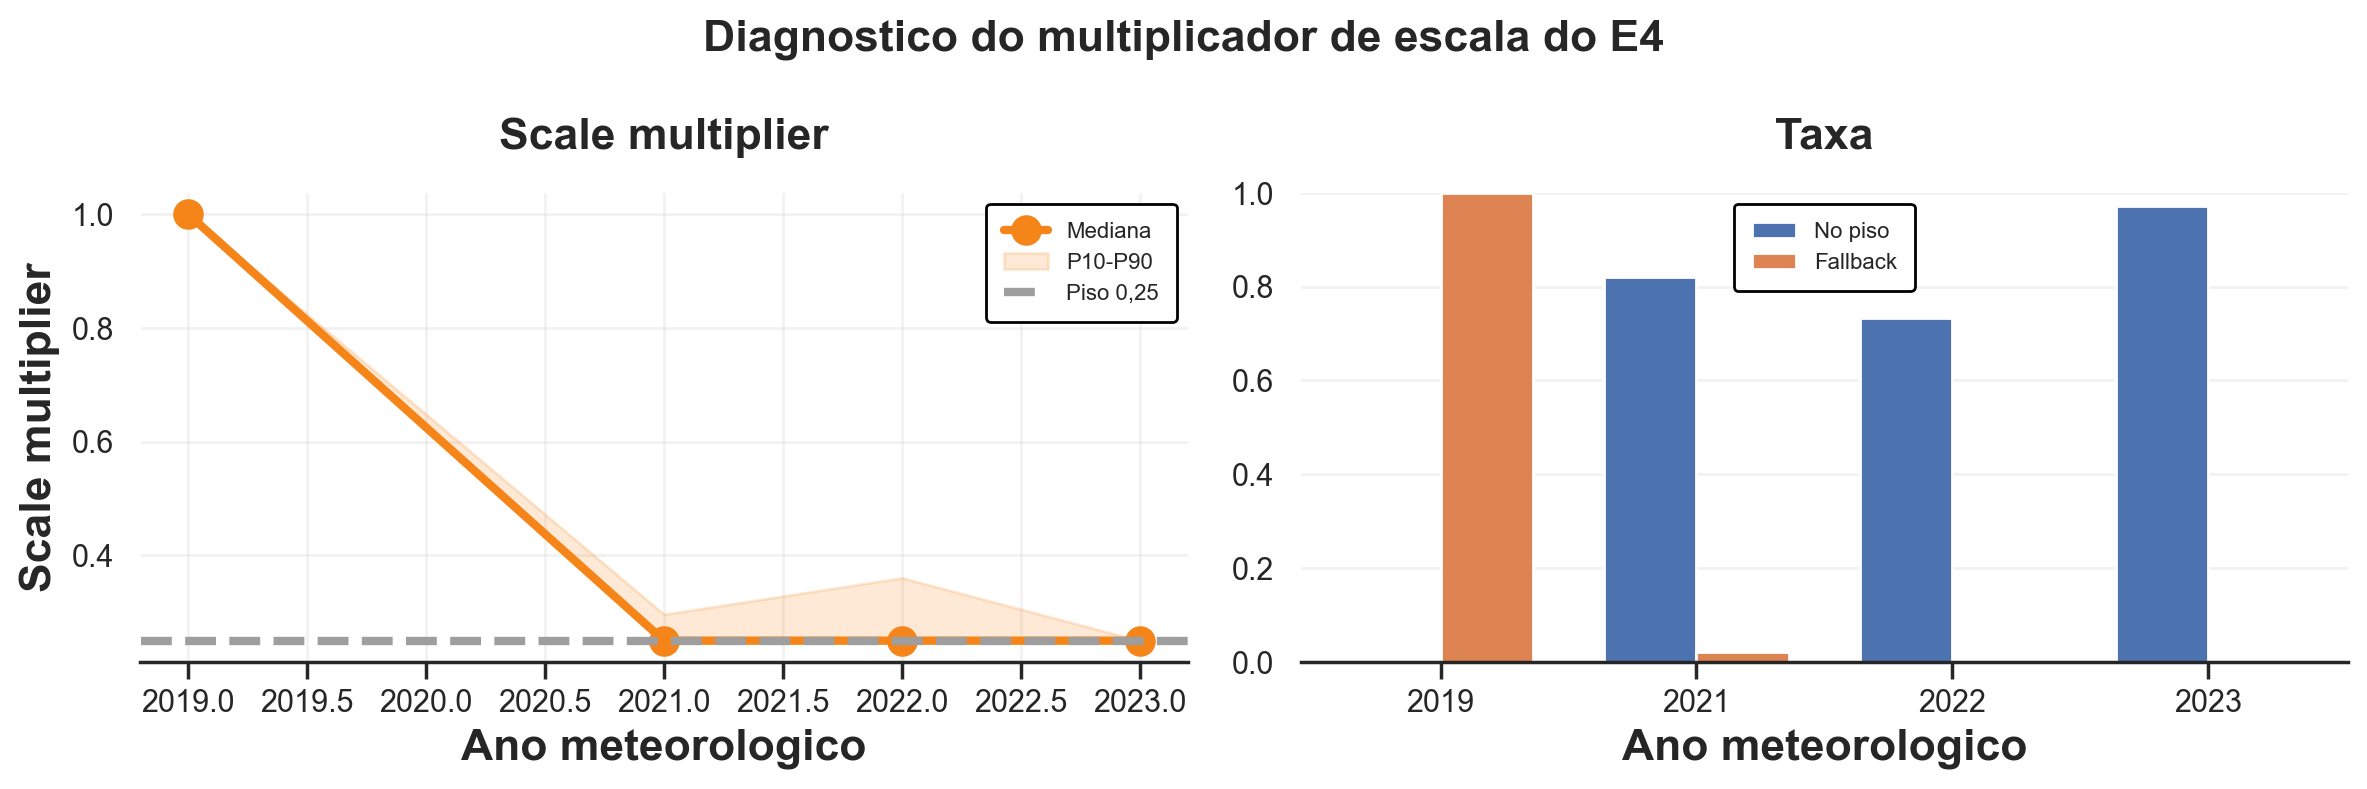

In [13]:
display(reports.residual_dependence_report(results, lang=lang))
display(reports.scale_diagnostics_report(results, lang=lang))
display(reports.plot_residual_dependence(results, lang=lang))
display(reports.plot_residual_diagnostics_heatmap(results, lang=lang))
reports.plot_scale_diagnostics(results, lang=lang)

In [14]:
reports.ablation_report(results, lang=lang)

,Experimento,Referencia,Delta MAE ponderado,Delta R2 ponderado
0,E1,E0,100.142887,-0.027985
1,E2,E0,141.414019,-0.039819
2,E3,E0,89.306232,-0.027251
3,E4,E3,0.000000,0.000000


## 13. Decisão experimental e segmentos

A sexta-feira às 18h foi motivada previamente pelos resíduos da validação final e continua sendo acompanhada como segmento de estresse, não como critério isolado de escolha. Também são verificadas métricas por rush period, estação, chuva e nível de demanda prevista, porque a subcobertura probabilística pode ficar concentrada em regimes operacionais específicos.

A decisão experimental foi separada em duas camadas. O sucessor pontual somente seria considerado se MAE e R² fossem melhorados nos folds normais de seleção. A camada de incerteza somente seria considerada como hipótese probabilística se a cobertura empírica, a largura e o Winkler score fossem defensáveis sem reabrir o holdout.

,Experimento,Segmento,Valor,Observacoes,MAE,rmse,R2,wape,Bias medio,Cobertura 90%,Largura media 90%
0,E0,Rush_Period,Evening Rush,3876,1498.923348,2120.534999,0.824642,0.198607,-811.092424,NaN,NaN
1,E0,Rush_Period,Morning Rush,2910,1324.147785,1985.300369,0.748503,0.240824,-897.677800,NaN,NaN
2,E0,Rush_Period,Non-Rush,27464,669.375987,1008.396147,0.865101,0.227647,-287.570018,NaN,NaN
22,E1,Rush_Period,Evening Rush,3876,1703.802306,2372.042799,0.780579,0.225753,-1015.529084,NaN,NaN
23,E1,Rush_Period,Morning Rush,2910,1491.317499,2178.133845,0.697274,0.271227,-1007.473935,NaN,NaN
24,E1,Rush_Period,Non-Rush,27464,729.581399,1089.246672,0.842602,0.248122,-355.307291,NaN,NaN
44,E2,Rush_Period,Evening Rush,3876,1754.239996,2485.962006,0.758997,0.232436,-916.237435,0.995872,33651.182920
45,E2,Rush_Period,Morning Rush,2910,1427.691602,2141.783292,0.707294,0.259655,-787.922449,0.994502,24175.125324
46,E2,Rush_Period,Non-Rush,27464,753.022548,1145.658906,0.825877,0.256094,-293.514846,0.995631,13466.447186
66,E3,Rush_Period,Evening Rush,3876,1648.873330,2384.009678,0.778359,0.218475,-1025.974813,0.994582,33107.628303


,Experimento,Segmento,Valor,Observacoes,MAE,rmse,R2,wape,Bias medio,Cobertura 90%,Largura media 90%
3,E0,Seasons,Autumn,8691,1171.376300,1773.803416,0.786246,0.263590,-885.148521,NaN,NaN
4,E0,Seasons,Spring,8832,741.801805,1130.671030,0.906014,0.185260,-251.090571,NaN,NaN
5,E0,Seasons,Summer,8831,998.018113,1349.694726,0.867213,0.221739,-312.314382,NaN,NaN
6,E0,Seasons,Winter,7896,316.782690,516.000108,0.881880,0.203769,-124.791488,NaN,NaN
25,E1,Seasons,Autumn,8691,1211.702054,1834.203842,0.771441,0.272664,-943.112149,NaN,NaN
26,E1,Seasons,Spring,8832,955.661171,1466.332752,0.841928,0.238670,-451.872230,NaN,NaN
27,E1,Seasons,Summer,8831,1047.335742,1410.411468,0.854997,0.232697,-358.924509,NaN,NaN
28,E1,Seasons,Winter,7896,349.616419,551.670662,0.864985,0.224889,-160.703364,NaN,NaN
47,E2,Seasons,Autumn,8691,1258.351303,1921.879069,0.749068,0.283162,-956.431056,0.995282,17777.521790
48,E2,Seasons,Spring,8832,910.376638,1396.539595,0.856618,0.227361,-271.679566,0.996037,18923.967253


,Experimento,Segmento,Valor,Observacoes,MAE,rmse,R2,wape,Bias medio,Cobertura 90%,Largura media 90%
7,E0,Rainfall Cat,Heavy Rain,191,434.056049,1050.097731,0.242539,0.708933,-349.421412,NaN,NaN
8,E0,Rainfall Cat,Light Rain,1558,655.092371,1135.427407,0.459152,0.566126,-317.313675,NaN,NaN
9,E0,Rainfall Cat,Moderate Rain,360,321.010858,742.713145,0.610918,0.576983,-173.178023,NaN,NaN
10,E0,Rainfall Cat,No Rain,32141,834.688918,1301.072656,0.868555,0.216547,-405.413688,NaN,NaN
29,E1,Rainfall Cat,Heavy Rain,191,464.360765,1090.041936,0.183817,0.758429,-314.573503,NaN,NaN
30,E1,Rainfall Cat,Light Rain,1558,671.509044,1151.458406,0.443772,0.580313,-340.267443,NaN,NaN
31,E1,Rainfall Cat,Moderate Rain,360,381.232440,948.865004,0.364951,0.685225,-115.982799,NaN,NaN
32,E1,Rainfall Cat,No Rain,32141,924.325550,1428.448687,0.841558,0.239802,-497.623761,NaN,NaN
51,E2,Rainfall Cat,Heavy Rain,191,446.112134,1043.876752,0.251487,0.728623,-297.977924,0.905759,2258.532060
52,E2,Rainfall Cat,Light Rain,1558,657.466409,1125.390322,0.468672,0.568177,-343.918612,0.967908,5368.228501


,Experimento,Segmento,Observacoes,MAE,RMSE,R2,wape,Bias medio
0,E0,Friday 18h,203,1878.767604,2466.476500,0.826522,0.183097,-851.915697
1,E1,Friday 18h,203,2153.950838,2820.065486,0.773218,0.209915,-1148.243147
2,E2,Friday 18h,203,2002.750803,2688.336915,0.793910,0.195180,-682.408677
3,E3,Friday 18h,203,1892.791097,2612.038182,0.805442,0.184464,-850.849699
4,E4,Friday 18h,203,1892.791097,2612.038182,0.805442,0.184464,-850.849699


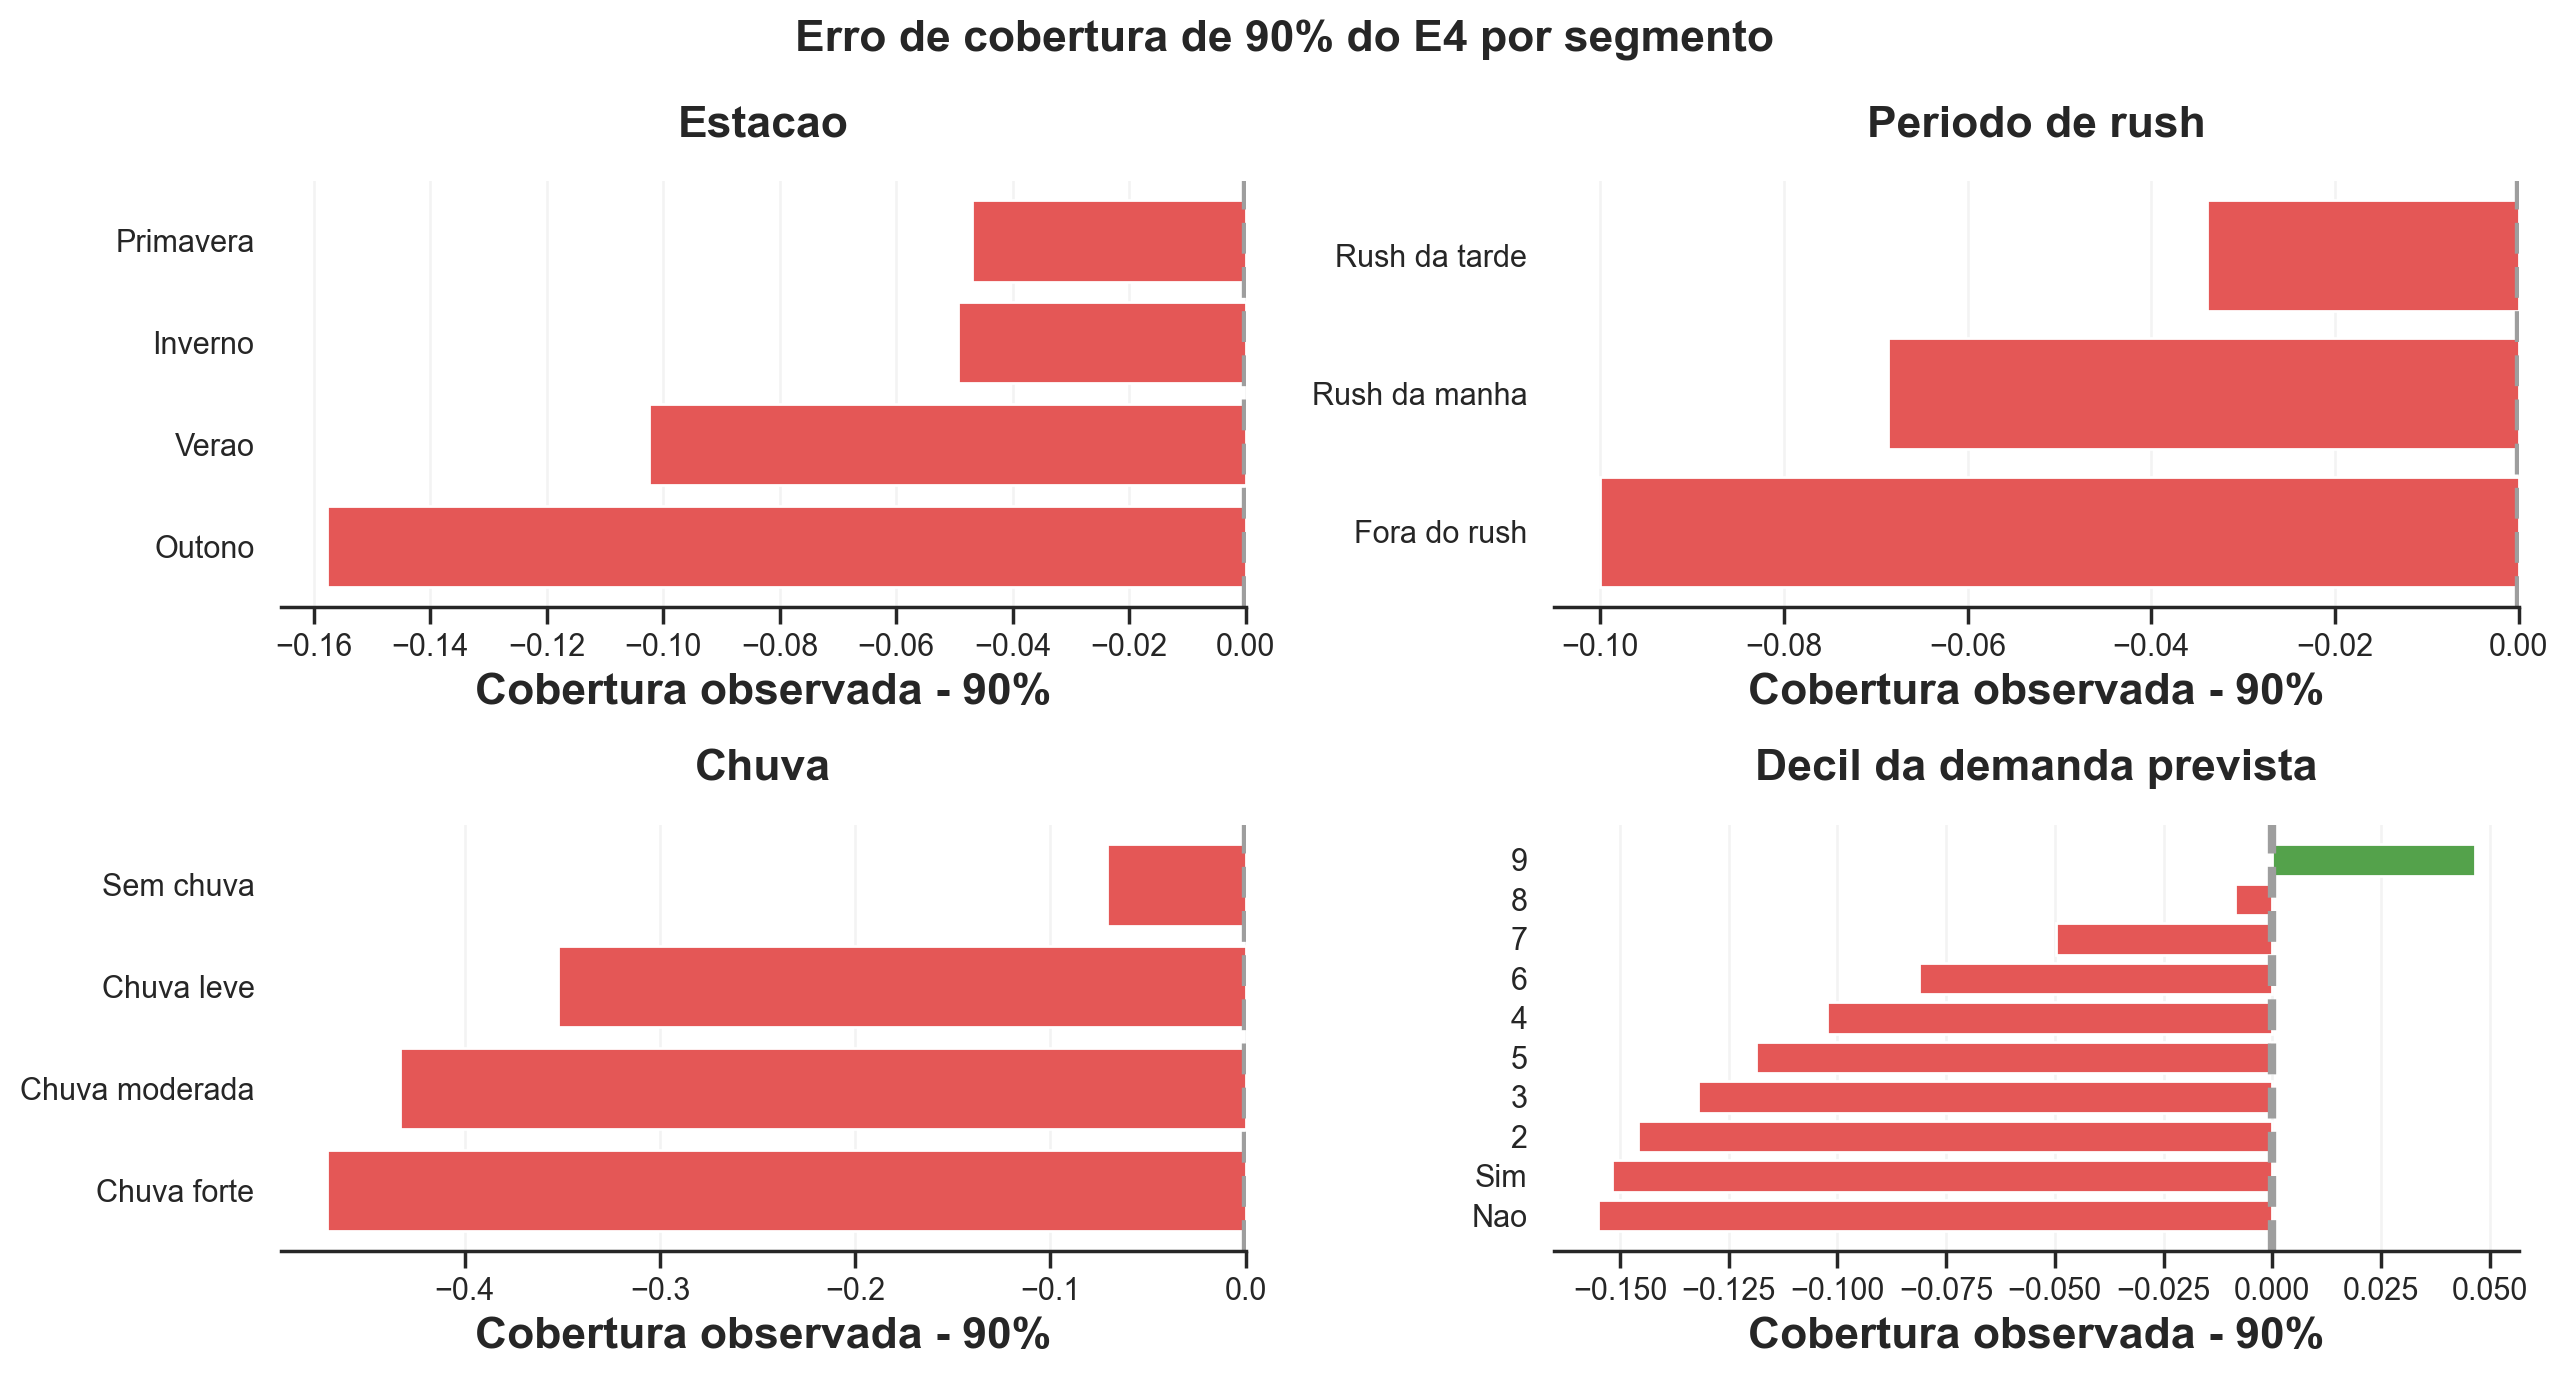

'Nenhum sucessor pontual foi identificado. O Champion E0 foi preservado, enquanto o E4 permaneceu apenas como candidato experimental para modelagem da incerteza, ainda dependente de calibracao adicional.'

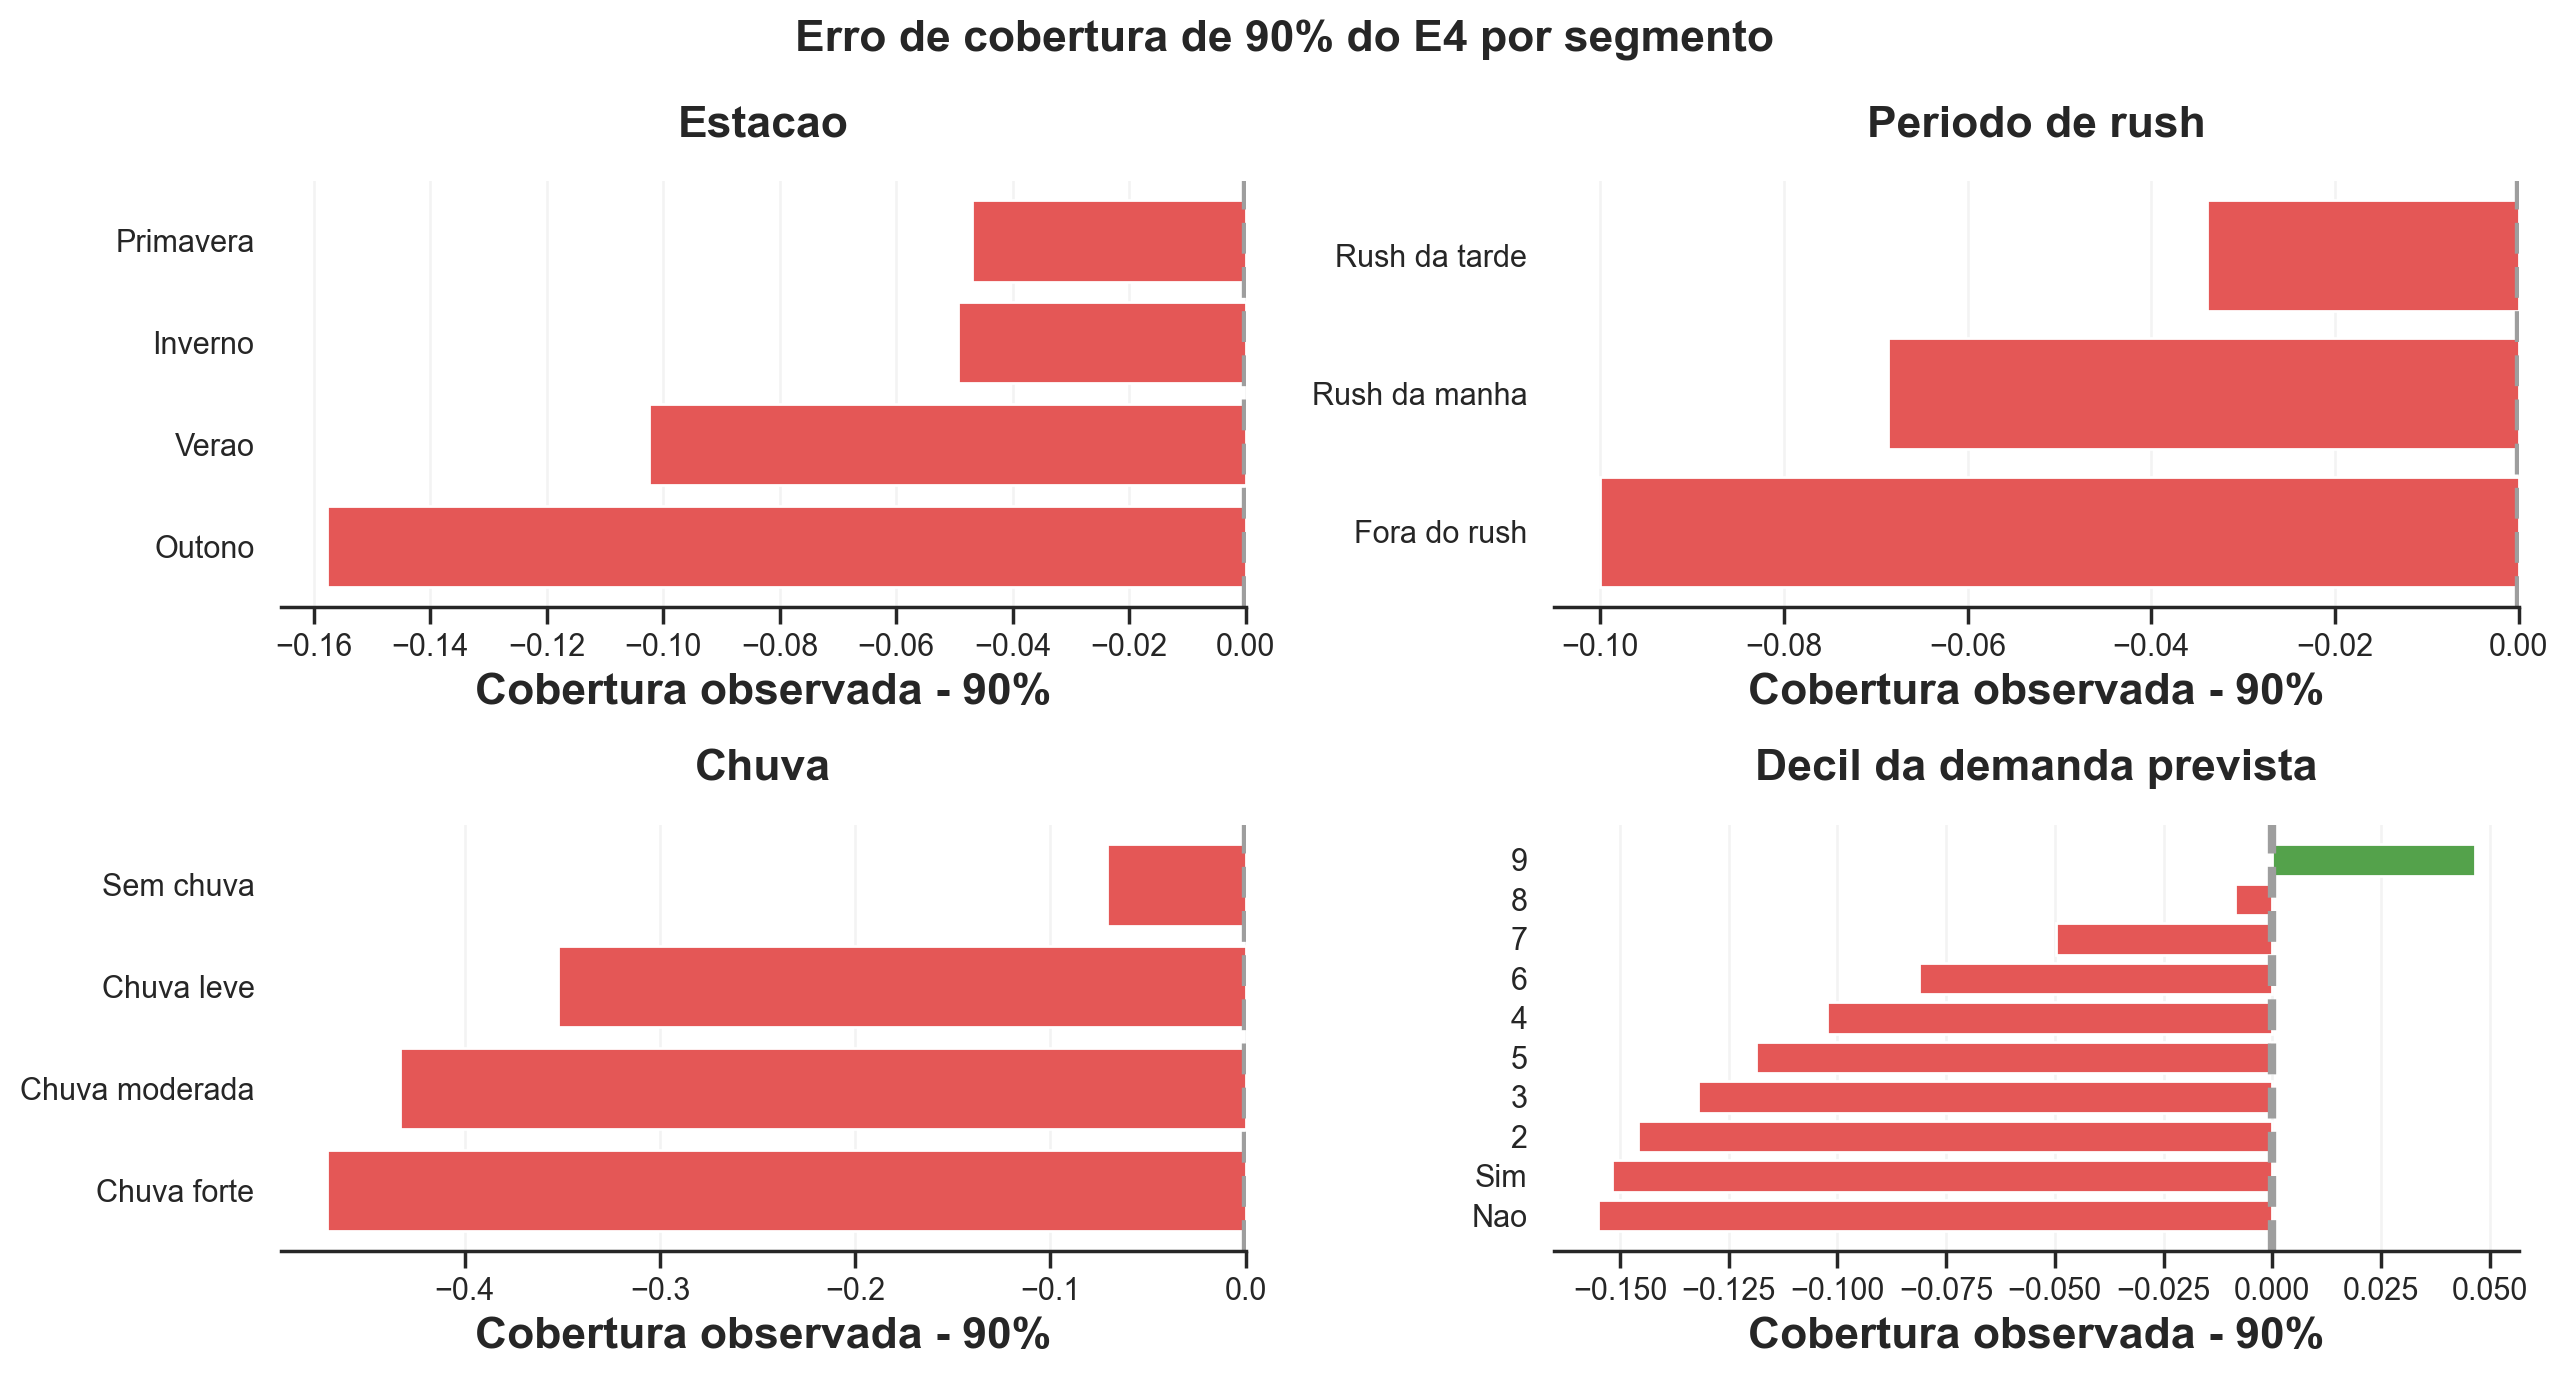

In [15]:
display(reports.segment_metrics_report(results, 'Rush_Period', lang=lang))
display(reports.segment_metrics_report(results, 'Seasons', lang=lang))
display(reports.segment_metrics_report(results, 'Rainfall Cat', lang=lang))
display(reports.friday_18_report(results, lang=lang))
display(reports.plot_segment_coverage(results, lang=lang))
reports.successor_message(results, lang=lang)

### Insight

>O E0 foi preservado como Champion pontual. Nos folds normais, o MAE ponderado permaneceu em 840,165, com R² ponderado de 0,857 e R² médio de 0,839. E1, E2 e E3 não reduziram o erro pontual, enquanto E4 manteve exatamente o ponto de E3 e, portanto, não pode ser tratado como sucessor pontual.
>
>O E4 foi mantido apenas como candidato experimental para a camada de incerteza. A largura média do intervalo de 90% foi reduzida para 4.501,5 bicicletas/hora e o Winkler score caiu para 6.530,4, mas a cobertura observada ficou em 81,0%. Como o multiplicador de escala foi comprimido com frequência no piso de 0,25, a próxima hipótese deverá ser uma calibração temporal adicional, sem uso do holdout.

## 14. Síntese

A arquitetura dinâmica foi preservada: o baseline E0 foi reconstruído do manifesto e todos os componentes treináveis continuaram dentro do pipeline. As novas hipóteses foram acopladas como blocos explícitos de experimento, sem modificar o Champion já congelado.

A leitura final foi separada em três perguntas. A primeira avaliou se o valor central melhorou, e a resposta foi negativa. O E0 permaneceu com MAE ponderado de 840,165, R² ponderado de 0,857 e R² médio de 0,839. E1 aumentou o MAE ponderado para 940,308, E2 aumentou para 981,579, e E3/E4 permaneceram em 929,472, com R² ponderado de 0,830.

A segunda pergunta avaliou se os intervalos ficaram calibrados. E2 e E3 ficaram superdispersos, com cobertura de 90% próxima de 99,5% e largura média superior a 16 mil bicicletas/hora. E4 reduziu a negative log-likelihood para 0,946, estreitou o intervalo médio de 90% para 4.501,5 e reduziu o Winkler score para 6.530,4, mas ficou subcalibrado ao entregar apenas 81,0% de cobertura observada.

A terceira pergunta avaliou se a dependência temporal da variância foi reduzida de forma operacionalmente utilizável. A resposta também foi negativa. A autocorrelação dos resíduos, a autocorrelação dos resíduos quadráticos e os diagnósticos ARCH permaneceram elevados, e o E0 continuou mais defensável como Champion pontual.

Nenhum sucessor pontual deve ser congelado a partir deste notebook. A próxima hipótese experimental foi definida como calibração conformal temporal sobre E0 e/ou E4, a ser tratada em um futuro Notebook 07. O holdout não foi reaberto nesta etapa, e qualquer candidato futuro continuará exigindo nova janela independente antes de confirmação.

### Referência metodológica

Prokhorenkova, L.; Gusev, G.; Vorobev, A.; Dorogush, A. V.; Gulin, A. (2018). CatBoost: unbiased boosting with categorical features. Advances in Neural Information Processing Systems 31.

Malinin, A.; Prokhorenkova, L.; Ustimenko, A. (2021). Uncertainty in Gradient Boosting via Ensembles. 9th International Conference on Learning Representations.

Duan, T.; Avati, A.; Ding, D. Y.; Thai, K. K.; Basu, S.; Ng, A.; Schuler, A. (2020). NGBoost: Natural Gradient Boosting for Probabilistic Prediction. Proceedings of the 37th International Conference on Machine Learning.

Engle, R. F. (1982). Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation. Econometrica, 50(4), 987-1007.

Gneiting, T.; Balabdaoui, F.; Raftery, A. E. (2007). Probabilistic Forecasts, Calibration and Sharpness. Journal of the Royal Statistical Society: Series B, 69(2), 243-268.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359-378.

Bergmeir, C.; Hyndman, R. J.; Koo, B. (2018). A note on the validity of cross-validation for evaluating autoregressive time series prediction. Computational Statistics & Data Analysis, 120, 70-83.